# Module 4 — Physics-Informed Symmetry: **Equivariant Graph Networks**
### TIFR ML School 2026 · *Sets, Graphs & Symmetry for High-Energy Physics*

Every model so far (DeepSets, ParticleNet, ParT) is built in only **one** symmetry: permutation. But physics has
*more*. A top quark is a top quark however the event is **rotated**, **translated**, or **Lorentz-boosted** — a
detector in a different orientation, or an observer in a different frame, must reach the same conclusion. This
module **bakes those symmetries into the network** as a hard inductive bias.

> **The one new ingredient: a group symmetry beyond permutation.** We constrain the *functions* the network can
> represent so that transforming the input by a group element $g$ transforms the output predictably
> ($f(\rho_g x)=\rho'_g f(x)$). The aggregation is still the Deep Sets pool — but now the messages may only be
> built from **group invariants**, and coordinate updates must transform **equivariantly**.

**What we will do:**
1. State the **equivariance condition**, *see* it on a 30-second toy, and build the two ingredients of the
   scalarization recipe — an invariant **scalar** and an equivariant **vector** — in a few lines each.
2. Implement an **E(n)-equivariant GNN (EGNN)**, **numerically verify** rotation+translation equivariance,
   *watch a vanilla GNN break it*, and **draw** the equivariant coordinate-update field.
3. Implement a **Lorentz-equivariant network (LorentzNet-lite)** from Minkowski invariants; see why the
   **metric** must change (Euclidean distance is not boost-invariant), and **verify that a Lorentz boost leaves
   its output unchanged** — uniformly over the whole group.
4. Run the headline experiment: **equivariant vs non-equivariant accuracy vs training-set size**; ask whether
   **data augmentation** can substitute for a built-in symmetry (it can't quite); and close with **equivariant
   regression** — a vector output a purely invariant net cannot produce.
5. Reach the frontier: build and verify the core of **L-GATr** (Lorentz-Equivariant Geometric Algebra Transformer) —
   a spacetime geometric algebra, its group action, equivariant linear maps *as the representation's commutant*, and
   **Lorentz-invariant attention** — then train it to tag jets.

**Dependencies:** `numpy torch torch_geometric matplotlib scikit-learn uproot awkward` (the L-GATr core in §8 needs
only `torch`).


## 1 · Symmetry, equivariance, invariance

A symmetry is a group $G$ acting on data. A map $f:X\to Y$ is **equivariant** if it commutes with the group:
$$ f(\rho_g\, x) = \rho'_g\, f(x)\quad\text{for all } g\in G, $$
where $\rho_g$ acts on the input and $\rho'_g$ on the output. **Invariance** is the special case where the output
does not transform at all ($\rho'_g=\mathrm{id}$) — what we want for a *classifier* (the label can't depend on the
frame). The pattern, exactly as in Module 1: stack **equivariant** layers, finish with an **invariant** readout.

Groups we care about in HEP:
- **Permutation** $S_N$ — particle ordering (Modules 1–3).
- **E(3)** — 3-D rotations + translations (calorimeter geometry; the EGNN below).
- **Lorentz $\mathrm{SO}^+(3,1)$** — boosts + rotations of 4-momenta (the deep one; LorentzNet below).

Why bother, when a big Transformer can *learn* approximate symmetry from data? Because building it in (i) guarantees
the symmetry **exactly**, for every input, and (ii) shrinks the hypothesis space, which typically means **better
generalization from less data** — the experiment in §5.

## 2 · Two ways to build an equivariant network

There are two dominant design philosophies — worth knowing which camp a paper is in:

- **Scalarization / invariant-feature.** Build all messages out of **invariants** of the group (Euclidean
  distances, Minkowski dot products), feed them through ordinary MLPs, and update coordinates by
  **invariant-weighted sums of equivariant vectors**. Simple, robust, no special algebra. → **EGNN** (E(n)),
  **LorentzNet**, **PELICAN** (permutation-equivariant + Lorentz). *This is what we implement.*
- **Steerable / equivariant-feature.** Carry features in **group representations** (vectors, tensors,
  spherical harmonics) and combine them with equivariant operations (tensor products, Clebsch–Gordan). More
  expressive, heavier machinery. → **LGN** (Lorentz Group Network), **Tensor-Field Networks**. *We discuss in §6.*

In [1]:

%matplotlib inline
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch_geometric.utils import scatter
from torch_geometric.nn import global_mean_pool, global_add_pool
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

torch.manual_seed(0); np.random.seed(0)
device = (torch.device("cuda") if torch.cuda.is_available()
          else torch.device("mps") if torch.backends.mps.is_available()
          else torch.device("cpu"))
print("device", device)

def mlp(i, o, h=64):
    return nn.Sequential(nn.Linear(i, h), nn.SiLU(), nn.Linear(h, h), nn.SiLU(), nn.Linear(h, o))

def fc_edge_index(batch):
    """Fully-connected edges WITHIN each graph (frame-independent, unlike a k-NN graph).
    Returns edge_index [2, E] = [source j, target i]."""
    same = batch.unsqueeze(0) == batch.unsqueeze(1)
    same.fill_diagonal_(False)
    idx = same.nonzero(as_tuple=False)          # pairs (i, j) that are connected
    return torch.stack([idx[:, 1], idx[:, 0]], dim=0)

def random_rotation(dim=3):
    """A uniformly-random proper rotation in `dim` dims (det +1), via QR of a Gaussian matrix."""
    A = torch.randn(dim, dim); Q, _ = torch.linalg.qr(A)
    if torch.det(Q) < 0: Q[:, 0] = -Q[:, 0]     # flip a column to force a proper rotation (det +1)
    return Q


device mps


## 2a · Invariance you can *see* — a 30-second experiment

Before any graphs, watch the payoff on the simplest possible problem. The target is **rotation-invariant**: is a
2-D point inside or outside a circle ($\|x\|^2>c$)? We fit two classifiers on the *same* data — a **naive** MLP on
the raw coordinates $x$, free to learn any orientation-dependent boundary, and an **invariant** MLP on the single
invariant $\|x\|^2$, for which $f(Rx)=f(x)$ **exactly**. We track, as the training set grows, both **test accuracy**
and an **invariance-violation**: the spread of a point's predicted probability as we spin it through rotations. A
truly invariant model has *zero* spread — at every size.

### Reading the experiment cell

The next cell constructs a deliberately simple test of rotational invariance. Each input is a point $x=(x_1,x_2)$ in the plane. The label is determined only by its squared distance from the origin, $\lVert x\rVert^2=x_1^2+x_2^2$, so rotating the point must not change its label.

#### Generating the test set

```python
torch.manual_seed(1); Xte, Yte = ring(4000)
```

`torch.manual_seed(1)` fixes PyTorch's pseudo-random-number generator. Consequently, the random test points and the random rotations used later are repeatable: rerunning the cell starts from the same random sequence rather than drawing a different experiment each time.

`ring(4000)` returns 4000 points and their labels. With `Xte` of shape `(4000, 2)`, row `i` is the point `Xte[i] = (x_i1, x_i2)`. `Yte` has shape `(4000,)`; its `i`-th entry is the target class for that point. The label rule from `ring` is `1` when $x_{i1}^2+x_{i2}^2>1.8$ and `0` otherwise. Thus the decision boundary is a circle, not a preferred direction.

#### Test accuracy

```python
def accuracy(m):
    return (m(Xte).argmax(-1) == Yte).float().mean().item()
```

Here `m` is a classifier whose final output has two logits per input point. The tensor `m(Xte)` therefore has shape `(4000, 2)`. For one point, if the two logits are $(z_0,z_1)$, then `argmax(-1)` selects the index of the larger logit: class `0` when $z_0>z_1$, and class `1` when $z_1>z_0$. A softmax is not needed for this choice because softmax preserves the ordering of logits.

`m(Xte).argmax(-1) == Yte` compares the 4000 predicted class indices with the 4000 labels, producing a Boolean vector. `.float()` maps `True` to `1.0` and `False` to `0.0`; `.mean()` therefore computes the fraction of correct predictions; and `.item()` extracts that scalar as an ordinary Python number. This is the model's test accuracy.

#### Measuring the invariance violation

```python
def violation(m):                                       # std of P(class 1) across random rotations of each point
    ps = [F.softmax(m(Xte @ random_rotation(2).T), -1)[:, 1] for _ in range(16)]
    return torch.stack(ps).std(0).mean().item()
```

`random_rotation(2)` returns a $2\times2$ rotation matrix $R$. The multiplication `Xte @ R.T` applies that same rotation to every row of `Xte`: row $x_i$ becomes $x_iR^T$ (equivalently, $R x_i$ if points are represented as column vectors). A rotation changes the coordinates but preserves the radius because
$$\lVert Rx\rVert^2=(Rx)^T(Rx)=x^TR^TRx=x^Tx=\lVert x\rVert^2,$$
where $R^TR=I$. Therefore the correct label should be the same for every rotated copy of a point.

The list comprehension repeats this calculation 16 times. On each repetition:

1. A fresh random rotation is sampled.
2. The complete test set is rotated.
3. `m(...)` produces two logits for every rotated point, giving shape `(4000, 2)`.
4. `F.softmax(..., -1)` converts each pair of logits $(z_0,z_1)$ into probabilities
   $$p_c=\frac{e^{z_c}}{e^{z_0}+e^{z_1}}.$$
5. `[:, 1]` keeps only $p_1$, the predicted probability of class 1, giving a vector of shape `(4000,)`.

After the comprehension, `ps` contains 16 vectors of 4000 probabilities. `torch.stack(ps)` makes these a tensor of shape `(16, 4000)`: the first dimension indexes the random rotation and the second indexes the test point. `.std(0)` computes a standard deviation along dimension 0, so it produces 4000 values. For point `i`, that value is
$$\operatorname{std}_{r=1}^{16}\left[p_1(R_r x_i)\right],$$
the amount by which the model's class-1 probability changes when that one point is viewed under different rotations. Finally, `.mean()` averages these 4000 per-point standard deviations:
$$\frac{1}{4000}\sum_{i=1}^{4000}\operatorname{std}_{r=1}^{16}\left[p_1(R_r x_i)\right].$$

A rotation-invariant model satisfies $p_1(Rx)=p_1(x)$, so every set of 16 probabilities is identical and the standard deviation is exactly zero (up to floating-point roundoff). The naive model receives raw coordinates and must learn this symmetry from data, so its probabilities can wobble under rotation; a larger value of `violation(m)` means greater rotational sensitivity. Thus the experiment reports both task performance (`accuracy`) and whether the model respects the geometry built into the labels (`violation`).

### What does the `-1` in `F.softmax(..., -1)` mean?

The full expression in `violation` is:

```python
F.softmax(m(Xte @ random_rotation(2).T), -1)[:, 1]
```

`F.softmax(input, dim)` takes a tensor of scores and converts them into normalized probabilities along the dimension specified by `dim`. The value `-1` means **the last dimension of the tensor**.

For this classifier, `m(Xte)` has shape `(4000, 2)`:

- dimension `0` indexes the 4000 test points;
- dimension `1` indexes the two classes;
- dimension `-1` is another way to refer to the last dimension, which here is dimension `1`.

Therefore:

```python
F.softmax(m(Xte), -1)
```

applies softmax separately to the two class logits belonging to each test point. It does **not** normalize across the 4000 different test points. For one point with logits $(z_0,z_1)$, softmax computes

$$
p_0=\frac{e^{z_0}}{e^{z_0}+e^{z_1}},\qquad
p_1=\frac{e^{z_1}}{e^{z_0}+e^{z_1}}.
$$

The resulting probabilities satisfy $p_0+p_1=1$ for each point. For example:

```python
logits = torch.tensor([[2.0, 1.0],
                       [0.0, 3.0]])
F.softmax(logits, -1)
```

produces approximately:

```python
tensor([[0.7311, 0.2689],
        [0.0474, 0.9526]])
```

The first row represents one input whose class logits are `(2.0, 1.0)`, so its probabilities are approximately 73.11% for class 0 and 26.89% for class 1. The second row represents another input whose probabilities are approximately 4.74% for class 0 and 95.26% for class 1.

For a two-dimensional tensor, the following are equivalent:

```python
F.softmax(logits, -1)
F.softmax(logits, dim=1)
```

Using `-1` is more general because it always means “the final axis,” even if extra leading dimensions are added. For example, if model outputs had shape `(batch_size, number_of_particles, number_of_classes)`, then `dim=-1` would still normalize over the class scores for each particle rather than requiring the code to know the numerical index of that axis.

Finally, the `[:, 1]` after softmax selects column 1, namely the probability of class 1, for every test point. Thus in

```python
F.softmax(m(Xte @ random_rotation(2).T), -1)[:, 1]
```

the operations are: rotate the points, obtain two logits per point, normalize those two logits into class probabilities along the last dimension, and keep only $P(\text{class }1)$.

In [2]:
def ring(n):
    x = torch.randn(n, 2) * 1.2
    return x, ((x ** 2).sum(-1) > 1.8).long()          # label depends only on |x| -> rotation-invariant

class NaiveClf(nn.Module):                              # sees raw coordinates
    def __init__(self): super().__init__(); self.f = mlp(2, 2)
    def forward(self, x): return self.f(x)
class InvariantClf(nn.Module):                          # sees ONLY the invariant |x|^2  =>  f(Rx)=f(x) exactly
    def __init__(self): super().__init__(); self.f = mlp(1, 2)
    def forward(self, x): return self.f((x ** 2).sum(-1, keepdim=True))

def quickfit(m, X, Y, ep=400):
    # Create Adam, an adaptive gradient-based optimizer, for all trainable model parameters.
    opt = torch.optim.Adam(m.parameters(), 1e-2)
    # Repeat the optimization loop for the requested number of epochs.
    for _ in range(ep):
        # Clear gradients left over from the previous optimization step.
        opt.zero_grad()
        # Compute cross-entropy between the model's logits and the integer class labels.
        loss = F.cross_entropy(m(X), Y)
        # Differentiate the loss with respect to every trainable parameter.
        loss.backward()
        # Update the parameters using their newly computed gradients.
        opt.step()
    # Return the same model object after it has been optimized in place.
    return m
torch.manual_seed(1); Xte, Yte = ring(4000)
def accuracy(m):
    return (m(Xte).argmax(-1) == Yte).float().mean().item()
def violation(m):                                       # std of P(class 1) across random rotations of each point
    ps = [F.softmax(m(Xte @ random_rotation(2).T), -1)[:, 1] for _ in range(16)]
    return torch.stack(ps).std(0).mean().item()

print(f"{'train size':>10} | {'naive acc':>9} {'violation':>10} | {'invariant acc':>13} {'violation':>10}")
for ntr in [60, 120, 400]:
    torch.manual_seed(0); Xtr, Ytr = ring(ntr)
    na = quickfit(NaiveClf(), Xtr, Ytr); iv = quickfit(InvariantClf(), Xtr, Ytr)
    print(f"{ntr:>10} | {accuracy(na):>9.3f} {violation(na):>10.4f} | {accuracy(iv):>13.3f} {violation(iv):>10.4f}")
print("\n=> the invariant model needs less data to reach high accuracy, and its violation is 0 at every size:")
print("   'built-in' is EXACT for every input; 'learned' is only approximate and wobbles under rotation.")

train size | naive acc  violation | invariant acc  violation
        60 |     0.937     0.0589 |         0.997     0.0000
       120 |     0.983     0.0197 |         1.000     0.0000
       400 |     0.989     0.0102 |         0.999     0.0000

=> the invariant model needs less data to reach high accuracy, and its violation is 0 at every size:
   'built-in' is EXACT for every input; 'learned' is only approximate and wobbles under rotation.


## 2b · The two ingredients on a toy: an invariant *scalar* and an equivariant *vector*

Scalarization needs exactly two building blocks, and each is one line. From a small 3-D point cloud we build an
**invariant scalar** — the sum of pairwise distances, unchanged by any rotation/translation ($s(Rx+t)=s(x)$), which
a *classifier* reads out — and an **equivariant vector** — a weight-and-sum of centroid-relative positions, which
*rotates with* the cloud ($v(Rx+t)=R\,v(x)$), which you need to *predict a direction/momentum*. These two behaviours
($\rho'_g=\mathrm{id}$ vs $\rho'_g=R$) are the whole game; every layer below is a fancier version of them.

In [3]:
torch.manual_seed(0)
pts = torch.randn(6, 3)

def invariant_scalar(x):                    # sum of pairwise Euclidean distances: E(3)-invariant
    return torch.cdist(x, x).sum()
def equivariant_vector(x):                  # weighted sum of centroid-relative positions: rotates as R v
    xc = x - x.mean(0)
    return (xc.norm(dim=1, keepdim=True) * xc).sum(0)

R, t = random_rotation(3), torch.randn(3)
xg = pts @ R.T + t                          # rho_g x  (rotate + translate)
print(f"invariant  scalar  |s(x) - s(Rx+t)|   = {(invariant_scalar(pts) - invariant_scalar(xg)).abs():.2e}   (rho'=id)")
print(f"equivariant vector |R v(x) - v(Rx+t)| = {(equivariant_vector(pts) @ R.T - equivariant_vector(xg)).norm():.2e}   (rho'=R)")

invariant  scalar  |s(x) - s(Rx+t)|   = 7.63e-06   (rho'=id)
equivariant vector |R v(x) - v(Rx+t)| = 1.73e-06   (rho'=R)


## 3 · EGNN — an E(n)-equivariant graph layer

### The goal: update a graph without depending on its coordinate system

An EGNN represents a point cloud as a graph. Node $i$ has a coordinate $x_i\in\mathbb R^n$ and a learned feature
$h_i\in\mathbb R^H$. In this notebook, $x_i$ is a 3-D position and $h_i$ is a 16-dimensional feature vector. The
graph contains directed edges $j\to i$, meaning that node $j$ sends a message to node $i$.

The relevant symmetry group is $E(n)$, the group of Euclidean transformations: a rotation or reflection $R$ followed
by a translation $t$. With row-vector storage, the transformed coordinates used in the code are
$$\widetilde x_i=x_iR^T+t,$$
where $R^TR=I$. A model is **invariant** if its output does not change under this transformation. It is
**equivariant** if its output transforms in the same predictable way as the input. EGNN keeps node features
invariant, $\widetilde h_i'=h_i'$, while its coordinates are equivariant,
$\widetilde x_i'=x_i'R^T+t$.

### The EGNN update, in mathematics

For an edge $j\to i$, define the relative displacement and squared distance
$$d_{ij}=x_i-x_j,\qquad r_{ij}=\|d_{ij}\|^2=d_{ij}^Td_{ij}.$$
The edge message is
$$m_{ij}=\phi_e(h_i,h_j,r_{ij}),$$
where $\phi_e$ is an ordinary MLP. In the implementation, `self.phi_e` receives `[h[dst], h[src], d2]`, whose
dimension is $H+H+1=2H+1$.

Each destination node aggregates all messages arriving at it:
$$M_i=\sum_{j\in\mathcal N(i)}m_{ij}.$$
The feature update is a residual update,
$$h_i'=h_i+\phi_h(h_i,M_i),$$
implemented by concatenating `h` with `scatter(m, dst, ..., reduce="sum")` and applying `self.phi_h`. Because
$h_i$, $h_j$, and $r_{ij}$ are invariant, the message $m_{ij}$ and the updated feature $h_i'$ are invariant.

The coordinate update is
$$x_i'=x_i+c\,\operatorname{mean}_{j\in\mathcal N(i)}\left[\phi_x(m_{ij})\,d_{ij}\right],$$
where $c=0.1$ is the stabilizing scale in `EGNNLayer`, and $\phi_x$ maps the hidden message to one scalar weight.
In code, `self.phi_x(m)` has shape `(number_of_edges, 1)`. Multiplying it by `diff` gives one weighted vector per
edge, and `scatter(..., reduce="mean")` averages those vectors at each destination node.

### Why the layer is E(n)-equivariant

Under $\widetilde x_i=x_iR^T+t$, the relative displacement becomes
$$\widetilde d_{ij}=\widetilde x_i-\widetilde x_j=(x_iR^T+t)-(x_jR^T+t)=d_{ij}R^T.$$
The translation cancels because both endpoints receive the same $t$. The squared distance is unchanged:
$$\widetilde r_{ij}=\|d_{ij}R^T\|^2=d_{ij}R^TRd_{ij}^T=d_{ij}d_{ij}^T=r_{ij}.$$
Therefore the MLP sees exactly the same inputs after a rigid transformation:
$$\widetilde m_{ij}=\phi_e(h_i,h_j,\widetilde r_{ij})=\phi_e(h_i,h_j,r_{ij})=m_{ij}.$$
The feature aggregation and feature update are consequently unchanged, so $\widetilde h_i'=h_i'$.

For coordinates, $\phi_x(m_{ij})$ is an invariant scalar, while $d_{ij}$ transforms as a vector. Hence each update
term transforms as
$$\phi_x(\widetilde m_{ij})\widetilde d_{ij}=\phi_x(m_{ij})d_{ij}R^T.$$
The mean and the scalar factor $c$ preserve this transformation law. Thus
$$\widetilde x_i'=\widetilde x_i+c\,\operatorname{mean}_j[\phi_x(m_{ij})\widetilde d_{ij}]
=x_iR^T+t+\left(x_i'-x_i\right)R^T=x_i'R^T+t.$$
This is exactly the required E(n)-equivariance condition.

### Line-by-line correspondence with the implementation

```python
src, dst = edge_index
diff = x[dst] - x[src]
d2 = (diff ** 2).sum(-1, keepdim=True)
m = self.phi_e(torch.cat([h[dst], h[src], d2], dim=-1))
h = h + self.phi_h(torch.cat([h, scatter(m, dst, dim=0, dim_size=h.size(0), reduce="sum")], dim=-1))
x = x + self.c * scatter(self.phi_x(m) * diff, dst, dim=0, dim_size=x.size(0), reduce="mean")
```

- `src` and `dst` identify the source $j$ and destination $i$ of every edge.
- `diff` computes $d_{ij}=x_i-x_j$ for all edges simultaneously.
- `d2` computes the invariant $r_{ij}=\|x_i-x_j\|^2$.
- `phi_e` turns the two endpoint features and the invariant distance into messages.
- `scatter(..., reduce="sum")` computes $M_i=\sum_jm_{ij}$ for each destination node.
- `phi_h` updates node features using the old feature and the aggregated message.
- `phi_x(m) * diff` creates invariant-weighted relative vectors.
- `scatter(..., reduce="mean")` averages the coordinate updates for each node.
- The residual additions preserve the original feature and coordinate channels while applying the learned update.

The next cell evaluates the same layer on $(h_0,x_0)$ and on $(h_0,x_0R^T+t)$. It checks the feature residual
$\max_i|h_i'(x_0)-h_i'(x_0R^T+t)|$ and coordinate residual
$\max_i|x_i'(x_0)R^T+t-x_i'(x_0R^T+t)|$. Values around $10^{-7}$ are the expected float32 round-off level,
not a learned approximation.

In [4]:
class EGNNLayer(nn.Module):
    def __init__(self, hidden, c=0.1):
        super().__init__()
        self.phi_e = mlp(2 * hidden + 1, hidden)
        self.phi_h = mlp(2 * hidden, hidden)
        self.phi_x = nn.Linear(hidden, 1)
        self.c = c
    def forward(self, h, x, edge_index):
        src, dst = edge_index                                   # message j(src) -> i(dst)
        diff = x[dst] - x[src]
        d2 = (diff ** 2).sum(-1, keepdim=True)                  # invariant
        m = self.phi_e(torch.cat([h[dst], h[src], d2], dim=-1))
        h = h + self.phi_h(torch.cat([h, scatter(m, dst, dim=0, dim_size=h.size(0), reduce="sum")], dim=-1))
        x = x + self.c * scatter(self.phi_x(m) * diff, dst, dim=0, dim_size=x.size(0), reduce="mean")
        return h, x

### Verifying E(3) equivariance numerically

Apply a random rotation $R$ and translation $t$ to the input coordinates and pass them through the layer. The
output features $h'$ must be **unchanged** (invariant) and the output coordinates must satisfy
$x'(\text{transformed input}) = R\,x'(\text{input}) + t$ (equivariant). Both residuals should be ~0.

In [5]:

# random_rotation(dim) is now a shared helper (top of notebook). Test ONE EGNN layer under R, t in 3-D.
torch.manual_seed(1)
N = 12
h0 = torch.randn(N, 16); x0 = torch.randn(N, 3)
ei = fc_edge_index(torch.zeros(N, dtype=torch.long))
layer = EGNNLayer(16)

R, t = random_rotation(), torch.randn(3)
h1, x1 = layer(h0, x0, ei)                                      # original
h2, x2 = layer(h0, x0 @ R.T + t, ei)                            # transformed input
print(f"feature invariance   max|h'(x) - h'(Rx+t)|      = {(h1 - h2).abs().max().item():.2e}")
print(f"coord  equivariance  max|R x'(x)+t - x'(Rx+t)|  = {((x1 @ R.T + t) - x2).abs().max().item():.2e}")


feature invariance   max|h'(x) - h'(Rx+t)|      = 2.38e-07
coord  equivariance  max|R x'(x)+t - x'(Rx+t)|  = 7.15e-07


## 3a · A vanilla GNN is **not** equivariant — watch it break

Why insist that messages be built from invariants only? Because the obvious alternative — feed the raw coordinate
*components* $x_i-x_j$ into an MLP and let it emit a new coordinate vector — silently destroys the symmetry: an MLP
is not rotation-equivariant ($\mathrm{MLP}(Rv)\neq R\,\mathrm{MLP}(v)$). Here is that "naive GNN" beside EGNN, run
through the **same** E(3) test. EGNN's residuals sit at the float32 floor ($\sim\!10^{-7}$); the naive one is off by
a factor of $\sim\!10^5$.

### NaiveGNN in equations

For an edge $j\to i$, let $d_{ij}=x_i-x_j\in\mathbb{R}^3$. The naive layer uses the raw vector components directly:

$$
\begin{aligned}
 m_{ij} &= \phi_e\!\left(h_i, h_j, d_{ij}\right),\\
 \bar m_i &= \sum_{j\in\mathcal{N}(i)} m_{ij},\\
 h_i' &= h_i+\phi_h\!\left(h_i,\bar m_i\right),\\
 x_i' &= x_i+0.1\,\frac{1}{|\mathcal{N}(i)|}\sum_{j\in\mathcal{N}(i)}\phi_x(m_{ij}).
\end{aligned}
$$

Under a rigid transformation $x_i\mapsto \tilde x_i=Rx_i+t$, the displacement transforms as
$\tilde d_{ij}=Rd_{ij}$. An $E(3)$-equivariant layer would therefore need

$$
 h_i'(\tilde x)=h_i'(x)\quad\text{and}\quad x_i'(\tilde x)=R\,x_i'(x)+t.
$$

The naive layer fails in two places:

1. **Message failure:** $\phi_e(h_i,h_j,Rd_{ij})\neq\phi_e(h_i,h_j,d_{ij})$ in general, because an unconstrained MLP depends on the coordinate frame. Thus the scalar features $h_i'$ are not invariant.
2. **Coordinate-update failure:** $\phi_x(m_{ij})\in\mathbb{R}^3$ is an arbitrary vector. In general it does not rotate as $R\phi_x(m_{ij})$, so the update cannot rotate correctly with the input.

EGNN fixes both issues by feeding $\|d_{ij}\|^2$ (an invariant) to $\phi_e$ and multiplying the scalar output of $\phi_x$ by $d_{ij}$, which supplies the correct direction.

```mermaid
graph LR
    A["Input: features and coordinates"] --> B["Raw displacement: d_ij = x_i - x_j"]
    B --> C["Rigid transform: d_ij becomes R d_ij"]
    B --> D["Naive phi_e sees raw components"]
    C --> E["Naive phi_e sees different components"]
    D --> F["Messages m_ij"]
    E --> G["Different messages"]
    F --> H["Aggregate and update h_i"]
    G --> I["Different h_i: not invariant"]
    F --> J["Naive phi_x emits arbitrary vector"]
    J --> K["Coordinate update x_i"]
    K --> L["Update does not rotate with R"]
```

<!-- VS Code's notebook Markdown renderer does not execute Mermaid fences. The SVG-style HTML below is the rendered fallback for the same graph. -->
<table>
<tr><td align="center"><b>Input</b><br/>features and coordinates</td><td align="center">→</td><td align="center"><b>Raw displacement</b><br/><code>d_ij = x_i - x_j</code></td><td align="center">→</td><td align="center"><b>Rigid transform</b><br/><code>d_ij → R d_ij</code></td></tr>
<tr><td></td><td></td><td align="center">↙</td><td></td><td align="center">↘</td></tr>
<tr><td></td><td></td><td align="center"><b>Naive φ_e</b><br/>raw components</td><td></td><td align="center"><b>Naive φ_e</b><br/>different components</td></tr>
<tr><td></td><td>↘</td><td align="center"><b>Messages</b></td><td>↙</td><td align="center"><b>Different messages</b></td></tr>
<tr><td></td><td></td><td align="center">↓</td><td></td><td align="center">↓</td></tr>
<tr><td></td><td></td><td align="center"><b>Update h_i</b></td><td></td><td align="center"><b>h_i changes</b><br/>not invariant</td></tr>
<tr><td></td><td></td><td align="center">↓</td><td></td><td></td></tr>
<tr><td></td><td></td><td align="center"><b>Naive φ_x</b><br/>arbitrary vector</td><td></td><td></td></tr>
<tr><td></td><td></td><td align="center">↓</td><td></td><td></td></tr>
<tr><td></td><td></td><td align="center"><b>Coordinate update</b><br/>does not rotate with R</td><td></td><td></td></tr>
</table>


In [6]:
class NaiveGNNLayer(nn.Module):
    """The tempting-but-wrong design: raw coordinate components go straight into the MLPs."""
    def __init__(self, hidden):
        super().__init__()
        self.phi_e = mlp(2 * hidden + 3, hidden)   # 3 = the RAW diff vector (not the invariant |diff|^2)
        self.phi_h = mlp(2 * hidden, hidden)
        self.phi_x = mlp(hidden, 3)                # emits an arbitrary 3-vector, NOT aligned to (x_i - x_j)
    def forward(self, h, x, edge_index):
        src, dst = edge_index
        diff = x[dst] - x[src]
        m = self.phi_e(torch.cat([h[dst], h[src], diff], dim=-1))                       # breaks invariance
        h = h + self.phi_h(torch.cat([h, scatter(m, dst, dim=0, dim_size=h.size(0), reduce="sum")], dim=-1))
        x = x + 0.1 * scatter(self.phi_x(m), dst, dim=0, dim_size=x.size(0), reduce="mean")  # breaks equivariance
        return h, x

torch.manual_seed(1)
Rr, tr = random_rotation(), torch.randn(3)
print(f"{'layer':>24} | {'feature |Δh|':>13} | {'coord |Δx|':>11}")
for name, lyr in [("EGNN (invariant msgs)", EGNNLayer(16)), ("naive GNN (raw coords)", NaiveGNNLayer(16))]:
    ha, xa = lyr(h0, x0, ei)                                    # h0, x0, ei from the E(3) test cell above
    hb, xb = lyr(h0, x0 @ Rr.T + tr, ei)
    print(f"{name:>24} | {(ha - hb).abs().max().item():>13.2e} | {((xa @ Rr.T + tr) - xb).abs().max().item():>11.2e}")
print("\n=> EGNN: equivariant to numerical precision. Naive GNN: the symmetry is simply gone.")

                   layer |  feature |Δh| |  coord |Δx|
   EGNN (invariant msgs) |      2.38e-07 |    3.58e-07
  naive GNN (raw coords) |      4.28e-02 |    6.95e-03

=> EGNN: equivariant to numerical precision. Naive GNN: the symmetry is simply gone.


## 3b · Equivariance **composes** — and a picture of the equivariant vector field

Two facts make EGNN usable as a *deep* network. (1) A stack of equivariant layers is still equivariant — the
property composes, so we can go deep without ever leaking the symmetry. (2) The coordinate update
$\Delta x_i=\sum_j\phi_x(m_{ij})(x_i-x_j)$ is a genuine **equivariant vector field**: rotate the input and the whole
field of update arrows rotates rigidly with it. We verify (1) on a 6-layer stack, then *draw* (2) in 2-D.

### Math outline: why depth preserves equivariance

Write an $E(3)$ transformation as $g=(R,t)$, acting on coordinates by
$T_g(x_i)=Rx_i+t$ while leaving invariant features unchanged. For one EGNN layer, define
$d_{ij}=x_i-x_j$ and

$$
\begin{aligned}
d_{ij} &\mapsto \tilde d_{ij}=(Rx_i+t)-(Rx_j+t)=R d_{ij},\\
s_{ij} &= \|d_{ij}\|^2 \mapsto \|R d_{ij}\|^2=s_{ij},\\
m_{ij} &= \phi_e(h_i,h_j,s_{ij}) \mapsto \tilde m_{ij}=m_{ij}.
\end{aligned}
$$

The message is a scalar/invariant because the only coordinate input to $\phi_e$ is the invariant squared distance.
Therefore aggregation and the feature update remain invariant:

$$
\bar m_i=\sum_{j\in\mathcal N(i)}m_{ij},\qquad
h_i'=h_i+\phi_h(h_i,\bar m_i),\qquad
\tilde h_i'=h_i'.
$$

For coordinates, $\phi_x(m_{ij})$ is a scalar weight. Hence

$$
\begin{aligned}
\Delta x_i
 &= c\,\operatorname{Agg}_{j\in\mathcal N(i)}\!\left[\phi_x(m_{ij})d_{ij}\right],\\
\Delta\tilde x_i
 &= c\,\operatorname{Agg}_{j\in\mathcal N(i)}\!\left[\phi_x(\tilde m_{ij})\tilde d_{ij}\right]
 =R\Delta x_i,\\
\tilde x_i'
 &=\tilde x_i+\Delta\tilde x_i
 =R(x_i+\Delta x_i)+t
 =R x_i'+t.
\end{aligned}
$$

The key is that every coordinate contribution is a scalar times a geometric vector. Translation cancels in $d_{ij}$,
and rotation factors out of the sum.

Now let $F$ denote one complete EGNN layer. If
$F(T_g(h,x))=T_g(F(h,x))$, then for a stack $F_L\circ\cdots\circ F_1$,

$$
\begin{aligned}
(F_L\circ\cdots\circ F_1)(T_g z)
&=F_L\!\left(T_g F_{L-1}\!\left(\cdots T_g F_1(z)\right)\right)\\
&=T_g(F_L\circ\cdots\circ F_1)(z).
\end{aligned}
$$

So equivariance is closed under composition: adding layers increases expressive depth without introducing a new symmetry
violation. The plotted arrows are precisely $\Delta x_i$; after rotating the input, each arrow becomes $R\Delta x_i$.

6-layer EGNN:  feature |Δh| = 2.38e-07   coord |Δx| = 4.77e-07


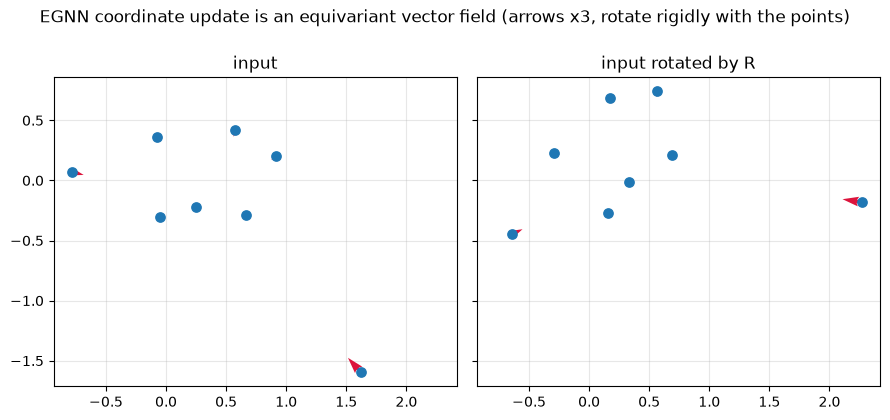

In [7]:
class EGNN(nn.Module):
    """A stack of EGNN layers with an input embedding. h -> invariant features, x -> equivariant coordinates."""
    def __init__(self, in_dim, hidden, layers):
        super().__init__()
        self.embed = nn.Linear(in_dim, hidden)
        self.layers = nn.ModuleList([EGNNLayer(hidden) for _ in range(layers)])
    def forward(self, h, x, edge_index):
        h = self.embed(h)
        for lyr in self.layers: h, x = lyr(h, x, edge_index)
        return h, x

# (1) equivariance of the whole 6-layer stack (reuse h0, x0, ei, Rr, tr from the cells above)
torch.manual_seed(2)
deep = EGNN(16, 32, layers=6)
ha, xa = deep(h0, x0, ei); hb, xb = deep(h0, x0 @ Rr.T + tr, ei)
print(f"6-layer EGNN:  feature |Δh| = {(ha - hb).abs().max().item():.2e}   "
      f"coord |Δx| = {((xa @ Rr.T + tr) - xb).abs().max().item():.2e}")

# (2) draw the update field Δx in 2-D, then rotate the input and redraw — the arrows rotate with it
torch.manual_seed(3)
P = torch.randn(8, 2); H = torch.randn(8, 16)
eip = fc_edge_index(torch.zeros(8, dtype=torch.long))
lyr2d = EGNNLayer(16)
Rot = random_rotation(2)
fig, axes = plt.subplots(1, 2, figsize=(9, 4.3), sharex=True, sharey=True)
for ax, (title, Q) in zip(axes, [("input", torch.eye(2)), ("input rotated by R", Rot)]):
    Xin = P @ Q.T
    _, Xout = lyr2d(H, Xin, eip)
    d = (Xout - Xin).detach() * 3.0                             # x3 for visibility; directions are exact
    ax.scatter(*Xin.T.numpy(), s=45, zorder=3)
    ax.quiver(Xin[:, 0].numpy(), Xin[:, 1].numpy(), d[:, 0].numpy(), d[:, 1].numpy(),
              angles="xy", scale_units="xy", scale=1, color="crimson", width=0.008, zorder=2)
    ax.set_title(title); ax.set_aspect("equal"); ax.grid(alpha=0.3)
fig.suptitle("EGNN coordinate update is an equivariant vector field (arrows x3, rotate rigidly with the points)")
plt.tight_layout(); plt.show()

## 4 · LorentzNet-lite — a Lorentz-equivariant network

Now the symmetry that matters most for jets: the **Lorentz group**. The coordinate of each particle is its
**4-momentum** $x_i=(E,p_x,p_y,p_z)$, transforming as $x_i\mapsto \Lambda x_i$ under a boost/rotation $\Lambda$.
The Lorentz invariants of a pair are the **Minkowski** dot products (metric $\mathrm{diag}(+,-,-,-)$):
$$ \langle a,b\rangle = a_0 b_0 - \vec a\!\cdot\!\vec b, \qquad \|x_i-x_j\|^2=\langle x_i-x_j,\,x_i-x_j\rangle. $$
The **LGEB** block (Gong et al., 2022) mirrors EGNN but with Minkowski invariants and a stabilizing
$\psi(s)=\mathrm{sgn}(s)\log(|s|+1)$:
$$
m_{ij}=\phi_e\big(h_i,h_j,\psi(\|x_i-x_j\|^2),\psi(\langle x_i,x_j\rangle)\big),\quad
h_i'=h_i+\phi_h(h_i,\textstyle\sum_j m_{ij}),\quad
x_i'=x_i+c\textstyle\sum_j \phi_x(m_{ij})(x_i-x_j).
$$
Because messages use **only Lorentz invariants**, $h$ is Lorentz-**invariant** and $x$ transforms as a 4-vector.
The graph is **fully connected** (every pair) — the only frame-independent choice. The final readout pools the
invariant $h$, so the classifier output is **Lorentz-invariant by construction**.

### Math and code outline

A particle is represented by a four-vector $x_i=(E_i,\mathbf p_i)$. With
$\eta=\mathrm{diag}(1,-1,-1,-1)$, the code's `minkowski(a, b)` computes

$$
\langle a,b\rangle_\eta=a^{\mathsf T}\eta b=a_0b_0-\mathbf a\cdot\mathbf b.
$$

A Lorentz transformation satisfies $\Lambda^{\mathsf T}\eta\Lambda=\eta$. Therefore

$$
\langle\Lambda a,\Lambda b\rangle_\eta=\langle a,b\rangle_\eta,
$$
so the pairwise quantities used by the network do not depend on the observer's inertial frame. This is the metric
replacement for the Euclidean $\|a-b\|^2$, which is not preserved by boosts.

The function `psi(s)` applies the signed-log stabilization
$\psi(s)=\operatorname{sgn}(s)\log(1+|s|)$. It is a scalar function of an invariant scalar, so $\psi(s)$ remains
invariant while compressing large dynamic ranges and retaining the sign of timelike/spacelike quantities.

For an edge $j\to i$, the `LGEB` block computes:

$$
\begin{aligned}
d_{ij} &= x_i-x_j, & q_{ij}&=\psi(\langle d_{ij},d_{ij}\rangle_\eta),\\
r_{ij} &=\psi(\langle x_i,x_j\rangle_\eta), &
m_{ij}&=\phi_e(h_i,h_j,q_{ij},r_{ij}).
\end{aligned}
$$

The concatenation in `torch.cat([h[dst], h[src], norm2, ip], dim=-1)` has dimension
$2H+2$: two $H$-dimensional invariant feature vectors plus the two scalar invariants. The MLP `phi_e` therefore
produces an invariant message. Mean aggregation is permutation-compatible over the fully connected edge set:

$$
\bar m_i=\operatorname{mean}_{j\in\mathcal N(i)}m_{ij},\qquad
h_i'=\operatorname{LayerNorm}\!\left(h_i+\phi_h(h_i,\bar m_i)\right).
$$

`LayerNorm` acts only on feature channels, so it cannot introduce frame dependence. If `update_coords=True`,
`phi_x` emits one scalar per edge and the coordinate update is

$$
x_i'=x_i+c\,\operatorname{mean}_{j\in\mathcal N(i)}
\left[\phi_x(m_{ij})(x_i-x_j)\right].
$$

Since $m_{ij}$ and $\phi_x(m_{ij})$ are Lorentz scalars while $d_{ij}$ is a four-vector, the update is equivariant:
$x_i'\mapsto\Lambda x_i'$. In this classifier, `update_coords=False`, so the input four-vectors remain fixed and only
the invariant features evolve. This is sufficient for invariant classification and avoids unnecessary coordinate
dynamics; the equivariant update is enabled later for vector-valued regression.

### LorentzNet-lite data flow

1. `p_jet = global_add_pool(x, batch)[batch]` constructs the total jet momentum $P=\sum_i x_i$ and broadcasts it to particles.
2. The initial embedding uses two per-particle Lorentz scalars:
$$h_i^{(0)}=\operatorname{Linear}\!\left(\psi(\langle x_i,x_i\rangle_\eta),\psi(\langle x_i,P\rangle_\eta)\right).$$
Because $P\mapsto\Lambda P$, both inner products are invariant.
3. `fc_edge_index(batch)` creates all within-jet particle pairs. A fully connected graph avoids a frame-dependent
k-nearest-neighbor choice.
4. The `n_layers` LGEB blocks update the invariant $h$; the classifier head applies LayerNorm, an MLP, and returns
class logits.
5. `global_mean_pool(h, batch)` removes the particle index while preserving invariance, so the final logits satisfy
$$f(\{\Lambda x_i\})=f(\{x_i\}).$$

In [8]:
def minkowski(a, b):
    """Minkowski inner product with metric (+,-,-,-).  a,b: (..., 4) -> (...,)"""
    return a[..., 0] * b[..., 0] - (a[..., 1:] * b[..., 1:]).sum(-1)

def psi(s):
    return torch.sign(s) * torch.log(torch.abs(s) + 1.0)

class LGEB(nn.Module):
    """Lorentz Group Equivariant Block (scalarization form).
    update_coords=True also evolves the 4-vectors equivariantly (as in EGNN). For a *classifier* we only need
    INVARIANCE, so we set it False and add a LayerNorm on the (invariant) features for stable training."""
    def __init__(self, hidden, c=0.01, update_coords=True):
        super().__init__()
        self.phi_e = mlp(2 * hidden + 2, hidden)
        self.phi_h = mlp(2 * hidden, hidden)
        self.phi_x = nn.Linear(hidden, 1)
        self.norm = nn.LayerNorm(hidden)
        self.c, self.update_coords = c, update_coords
    def forward(self, h, x, edge_index):
        src, dst = edge_index
        diff = x[dst] - x[src]
        norm2 = psi(minkowski(diff, diff)).unsqueeze(-1)             # invariant
        ip    = psi(minkowski(x[dst], x[src])).unsqueeze(-1)         # invariant
        m = self.phi_e(torch.cat([h[dst], h[src], norm2, ip], dim=-1))
        agg = scatter(m, dst, dim=0, dim_size=h.size(0), reduce="mean")
        h = self.norm(h + self.phi_h(torch.cat([h, agg], dim=-1)))   # LayerNorm preserves invariance (h is invariant)
        if self.update_coords:
            x = x + self.c * scatter(self.phi_x(m) * diff, dst, dim=0, dim_size=x.size(0), reduce="mean")
        return h, x

class LorentzNetLite(nn.Module):
    def __init__(self, hidden=64, n_layers=3, n_classes=2):
        super().__init__()
        self.embed = nn.Linear(2, hidden)                           # from two Lorentz scalars (see forward)
        # classifier needs only INVARIANCE -> disable the (equivariant) coordinate update for stability;
        # that update is exactly EGNN's and is needed only for equivariant *outputs* (Exercise 5).
        self.blocks = nn.ModuleList([LGEB(hidden, update_coords=False) for _ in range(n_layers)])
        self.head = nn.Sequential(nn.LayerNorm(hidden), nn.Linear(hidden, hidden), nn.SiLU(),
                                  nn.Linear(hidden, n_classes))
    def forward(self, data):
        x, batch = data.pos, data.batch
        # invariant per-particle init: its mass^2 and its Minkowski product with the JET 4-momentum
        # (P_jet = sum of 4-momenta transforms as a 4-vector, so <p_i, P_jet> is Lorentz-invariant).
        p_jet = global_add_pool(x, batch)[batch]
        h = self.embed(torch.stack([psi(minkowski(x, x)), psi(minkowski(x, p_jet))], dim=-1))
        edge_index = fc_edge_index(batch)
        for blk in self.blocks:
            h, x = blk(h, x, edge_index)
        return self.head(global_mean_pool(h, batch))                # invariant readout

## 4a · Lorentz transformations in code (and a metric sanity check)

To *test* Lorentz invariance we need Lorentz transforms to hit our jets with. A general (proper, orthochronous)
element is a **rotation** composed with a **boost** in some direction. Its defining property is that it preserves
the Minkowski metric $g=\mathrm{diag}(+,-,-,-)$: $\ \Lambda^{\mathsf T} g\,\Lambda = g$. We build the pieces,
assemble a random $\Lambda$, and confirm that identity numerically.

In [9]:
def rotation4(R3):                                  # embed a 3-D rotation into 4x4 (leaves the energy/time axis)
    L = torch.eye(4); L[1:, 1:] = R3; return L

def boost_matrix(beta):                             # general boost with 3-velocity beta (|beta| < 1)
    beta = torch.as_tensor(beta, dtype=torch.float32); b2 = (beta * beta).sum()
    gamma = 1.0 / torch.sqrt(1 - b2); L = torch.eye(4)
    L[0, 0] = gamma; L[0, 1:] = gamma * beta; L[1:, 0] = gamma * beta
    L[1:, 1:] = torch.eye(3) + (gamma - 1) * torch.outer(beta, beta) / b2
    return L

def boost_z(xi):                                    # boost along z with rapidity xi (used throughout below)
    c, s = math.cosh(xi), math.sinh(xi); L = torch.eye(4)
    L[0, 0] = c; L[0, 3] = s; L[3, 0] = s; L[3, 3] = c
    return L

def random_lorentz(max_beta=0.8):                   # random rotation * boost * rotation
    b = torch.randn(3); b = b / b.norm() * (torch.rand(1) * max_beta)
    return rotation4(random_rotation()) @ boost_matrix(b) @ rotation4(random_rotation())

g = torch.diag(torch.tensor([1., -1., -1., -1.]))
L = random_lorentz()
print(f"random Lorentz Λ preserves the metric:  max|ΛᵀgΛ - g| = {(L.T @ g @ L - g).abs().max().item():.2e}")
print(f"boost_z(0.4) matches the general boost:  {(boost_z(0.4) - boost_matrix([0, 0, math.tanh(0.4)])).abs().max().item():.2e}")

random Lorentz Λ preserves the metric:  max|ΛᵀgΛ - g| = 4.77e-07
boost_z(0.4) matches the general boost:  1.19e-07


## 4b · Why the **Minkowski** metric? Euclidean distance is not boost-invariant

EGNN's messages used the Euclidean $\|x_i-x_j\|^2$. For 4-momenta that is the *wrong* invariant: a Lorentz boost
mixes energy and momentum, so the naive squared distance $\sum_\mu(\Delta p_\mu)^2$ **changes**. The quantity that
stays fixed is the **Minkowski** norm $\langle\Delta p,\Delta p\rangle=\Delta E^2-\Delta\vec p^{\,2}$. Below we
boost five particles and print both — Euclidean moves, Minkowski does not. That single fact is *why* LorentzNet
swaps the metric.

In [10]:
torch.manual_seed(0)
p = torch.randn(5, 4)
p[:, 0] = p[:, 1:].norm(dim=1) + torch.rand(5) + 0.5          # give each a physical energy E > |p| (timelike)
pb = p @ boost_z(0.6).T                                       # boost the whole set along z
d, db = p[0:1] - p, pb[0:1] - pb                              # separations from particle 0, before/after boost
fmt = lambda v: "[" + ", ".join(f"{x:6.2f}" for x in v) + "]"
print("Euclidean  Σ(Δp)²   before boost:", fmt((d ** 2).sum(-1).tolist()))
print("Euclidean  Σ(Δp)²   after  boost:", fmt((db ** 2).sum(-1).tolist()), "  <- changed")
print("Minkowski ⟨Δp,Δp⟩   before boost:", fmt(minkowski(d, d).tolist()))
print("Minkowski ⟨Δp,Δp⟩   after  boost:", fmt(minkowski(db, db).tolist()), "  <- invariant")

Euclidean  Σ(Δp)²   before boost: [  0.00,   9.04,   4.89,  10.81,  13.18]
Euclidean  Σ(Δp)²   after  boost: [  0.00,  29.41,   7.28,  10.72,  17.14]   <- changed
Minkowski ⟨Δp,Δp⟩   before boost: [  0.00,  -1.76,  -3.81,  -7.39,  -9.10]
Minkowski ⟨Δp,Δp⟩   after  boost: [  0.00,  -1.76,  -3.81,  -7.39,  -9.10]   <- invariant


## 5 · Data: each jet as a set of 4-momenta

For a clean Lorentz demonstration we use the particles' **4-momenta** directly. We keep the **leading $N$
particles by energy** per jet (so fully-connected graphs stay cheap) and scale momenta to $\mathcal O(1)$ (a
Lorentz-*scalar* rescaling — it does not break the symmetry, it just helps float32 conditioning). Each PyG `Data`
stores `pos = x = ` the (scaled) 4-vectors; the equivariant model reads `pos`, the non-equivariant baseline reads
`x`.

In [11]:
import os, uproot, awkward as ak

CANDIDATE_PATHS = [
    "../data/JetClass_example_100k.root",
    "/Users/sanmay/Documents/ML_SCHOOLS/MLSCHOOL_2023_ICTS/Main_School/JetDataset/JetClass_example_100k.root",
    "./JetClass_example_100k.root",
]
root_path = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)
if root_path is None:
    raise FileNotFoundError("Place JetClass_example_100k.root in ../data/.")

NPART, N_PER_CLS, SCALE = 24, 8000, 0.01
tree = uproot.open(root_path)["tree"]
br = tree.arrays(["part_px","part_py","part_pz","part_energy","label_QCD","label_Tbqq","label_Tbl"])
is_qcd = ak.to_numpy(br["label_QCD"]).astype(bool)
is_top = ak.to_numpy(br["label_Tbqq"]).astype(bool) | ak.to_numpy(br["label_Tbl"]).astype(bool)
sel = np.concatenate([np.where(is_qcd)[0][:N_PER_CLS], np.where(is_top)[0][:N_PER_CLS]])
labels = np.concatenate([np.zeros(N_PER_CLS), np.ones(N_PER_CLS)]).astype(np.int64)

px,py,pz,e = br["part_px"][sel], br["part_py"][sel], br["part_pz"][sel], br["part_energy"][sel]
order = ak.argsort(e, axis=1, ascending=False)                  # leading particles by energy
def topN(a): return ak.to_numpy(ak.fill_none(ak.pad_none(a[order], NPART, clip=True), 0.0))
P4 = (np.stack([topN(e), topN(px), topN(py), topN(pz)], axis=-1).astype(np.float32)) * SCALE   # (Njet,N,4)
counts = np.minimum(ak.to_numpy(ak.num(e, axis=1)), NPART)

data_list = []
for i in range(len(labels)):
    n = int(counts[i])
    if n < 2: continue
    fm = torch.from_numpy(P4[i, :n])
    data_list.append(Data(x=fm, pos=fm, y=torch.tensor([int(labels[i])], dtype=torch.long)))

import random
random.seed(0); random.shuffle(data_list)
test_set = data_list[-3000:]
pool     = data_list[:-3000]
test_loader = DataLoader(test_set, batch_size=128)
print(f"{len(data_list)} jets | pool {len(pool)} | test {len(test_set)} | each jet <= {NPART} particles (4-vectors)")

16000 jets | pool 13000 | test 3000 | each jet <= 24 particles (4-vectors)


## 5a · The physics the network sees — and why the $\psi$ squashing

Two quick looks at the actual inputs. **First**, the most famous Lorentz invariant of a jet, its **invariant mass**
$M=\sqrt{\langle P,P\rangle}$ with $P=\sum_i p_i$: a top jet contains the decay of a heavy particle, so its mass
piles up at $\mathcal O(100\,\text{GeV})$, while a QCD jet is soft and light — the classes separate on this one
invariant alone, exactly the signal LorentzNet is built to exploit. **Second**, the raw pairwise invariants
$\langle p_i,p_j\rangle$ span *many orders of magnitude* (hard leading pairs vs soft radiation), which float32 and
MLPs both hate — that is what $\psi(s)=\mathrm{sgn}(s)\log(|s|+1)$ is for: compress the dynamic range while keeping
sign and monotonicity.

### Math outline: what this diagnostic is measuring

For a jet with particle four-momenta $p_1,\ldots,p_n$, the total four-momentum is
$P=\sum_{i=1}^n p_i$. Its invariant mass is

$$
M^2=\langle P,P\rangle_\eta=P_0^2-\|\mathbf P\|^2,
\qquad M=\sqrt{\max(M^2,0)}.
$$

A Lorentz transformation sends $P\mapsto\Lambda P$ but preserves $M^2$ because
$\Lambda^{\mathsf T}\eta\Lambda=\eta$. The first plot therefore shows a physically meaningful, frame-independent
one-dimensional feature. The different QCD and top-jet mass distributions explain why even this single invariant can
already carry classification information; LorentzNet-lite uses many such invariants jointly rather than relying on
mass alone.

The second diagnostic examines the pairwise matrix
$S_{ij}=\langle p_i,p_j\rangle_\eta$. Each entry is invariant, but its numerical scale can vary substantially:

$$
S_{ij}=E_iE_j-\mathbf p_i\!\cdot\!\mathbf p_j,
\qquad
\psi(S_{ij})=\operatorname{sgn}(S_{ij})\log(1+|S_{ij}|).
$$

For $s\neq0$, the derivative is $\psi'(s)=1/(1+|s|)$, so large magnitudes are compressed while the map remains
monotone separately on the positive and negative branches. The sign is retained: timelike-like and spacelike-like
configurations are not collapsed into the same value. Near zero, $\psi(s)\approx s$, so small pairwise invariants
remain numerically resolved.

In code, `topN` sorts particles by energy, pads or clips every jet to `NPART`, and `SCALE` keeps tensor values in a
well-conditioned numerical range. The printed eight-decade span is precisely the motivation for applying `psi`
before the MLPs: it reduces extreme feature scales without sacrificing Lorentz invariance or the ordering of values.

#### The signed-log squashing function

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 520 285" width="520" role="img" aria-label="Plot of psi of s equals sign of s times log of one plus absolute value of s">
  <rect width="520" height="285" fill="white"/>
  <text x="260" y="22" text-anchor="middle" font-family="sans-serif" font-size="16" font-weight="bold">ψ(s) = sgn(s) log(1 + |s|)</text>
  <line x1="50" y1="140" x2="490" y2="140" stroke="#555" stroke-width="1.5"/>
  <line x1="270" y1="40" x2="270" y2="240" stroke="#555" stroke-width="1.5"/>
  <line x1="50" y1="73" x2="490" y2="73" stroke="#ddd"/>
  <line x1="50" y1="207" x2="490" y2="207" stroke="#ddd"/>
  <path d="M50 60 L160 80 L226 98 L248 117 L270 140 L292 163 L314 182 L380 200 L490 220" fill="none" stroke="#2563eb" stroke-width="3"/>
  <text x="495" y="145" font-family="sans-serif" font-size="13">s</text>
  <text x="276" y="38" font-family="sans-serif" font-size="13">ψ(s)</text>
  <text x="45" y="158" text-anchor="end" font-family="sans-serif" font-size="12">0</text>
  <text x="270" y="258" text-anchor="middle" font-family="sans-serif" font-size="12">0</text>
  <text x="50" y="258" text-anchor="middle" font-family="sans-serif" font-size="12">−10</text>
  <text x="490" y="258" text-anchor="middle" font-family="sans-serif" font-size="12">10</text>
  <text x="260" y="280" text-anchor="middle" font-family="sans-serif" font-size="12" fill="#444">Large magnitudes are compressed; sign is preserved</text>
</svg>


jet mass median:   QCD  57.3 GeV    top 115.9 GeV
raw |<p_i,p_j>| spans ~8 decades across the bulk (1-99%), wider in the tails  ->  psi maps everything into [-0.00, 1.03]


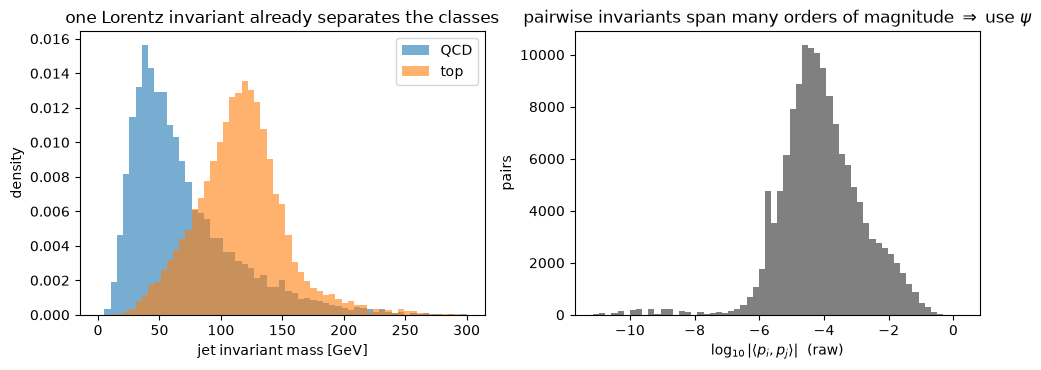

In [12]:
# jet invariant mass (a Lorentz scalar), in GeV -- undo the O(1) rescaling for a physical x-axis
P = P4.sum(axis=1) / SCALE                                   # jet 4-momentum = sum over constituents (zeros pad)
m2 = P[:, 0] ** 2 - (P[:, 1:] ** 2).sum(-1)
mjet = np.sqrt(np.clip(m2, 0, None))
print(f"jet mass median:   QCD {np.median(mjet[labels==0]):5.1f} GeV    top {np.median(mjet[labels==1]):5.1f} GeV")

# dynamic range of the pairwise Minkowski invariants (top jets), raw vs psi-squashed
vals = []
for i in np.where(labels == 1)[0][:300]:
    n = int(counts[i]); fm = torch.from_numpy(P4[i, :n])
    vals.append(minkowski(fm.unsqueeze(0), fm.unsqueeze(1)).flatten())
vals = torch.cat(vals); a = vals.abs(); a = a[a > 0]
q01, q99 = torch.quantile(a, 0.01).item(), torch.quantile(a, 0.99).item()
print(f"raw |<p_i,p_j>| spans ~{math.log10(q99 / q01):.0f} decades across the bulk (1-99%), wider in the tails "
      f" ->  psi maps everything into [{psi(vals).min().item():.2f}, {psi(vals).max().item():.2f}]")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
ax[0].hist(mjet[labels == 0], bins=np.linspace(0, 300, 60), alpha=0.6, density=True, label="QCD")
ax[0].hist(mjet[labels == 1], bins=np.linspace(0, 300, 60), alpha=0.6, density=True, label="top")
ax[0].set_xlabel("jet invariant mass [GeV]"); ax[0].set_ylabel("density"); ax[0].legend()
ax[0].set_title("one Lorentz invariant already separates the classes")
ax[1].hist(np.log10(a.numpy()), bins=60, color="gray")
ax[1].set_xlabel(r"$\log_{10}|\langle p_i,p_j\rangle|$  (raw)"); ax[1].set_ylabel("pairs")
ax[1].set_title(r"pairwise invariants span many orders of magnitude $\Rightarrow$ use $\psi$")
plt.tight_layout(); plt.show()

### The two contestants we will race

The experiment in §6 pits two permutation-invariant models against each other. One — **LorentzNet-lite** (above) —
*also* has Lorentz symmetry built in. The other — a plain **DeepSets** on the raw 4-vector components — does not.
Same pooling, same readout capacity; the *only* difference is the physical inductive bias. Here is the baseline.

In [13]:
class DeepSetsBaseline(nn.Module):
    """Permutation-invariant but NOT Lorentz-equivariant: a plain DeepSet on raw 4-vector components."""
    def __init__(self, hidden=64, n_classes=2):
        super().__init__()
        self.phi = mlp(4, hidden)
        self.head = nn.Sequential(nn.LayerNorm(hidden), nn.Linear(hidden, hidden), nn.SiLU(),
                                  nn.Linear(hidden, n_classes))
    def forward(self, data):
        return self.head(global_mean_pool(self.phi(data.x), data.batch))

## 5b · Verifying Lorentz invariance (the headline guarantee)

We take a batch of jets, apply a **Lorentz boost** $\Lambda$ along $z$ to every 4-momentum, and check that
LorentzNet-lite's output is **unchanged**. This holds for an *untrained* network — it is **architectural**, not
learned. (We also confirm the boost preserves each particle's invariant mass.)

In [14]:

# boost_z / random_lorentz live in §4a. Verify invariance on a real batch of jets (untrained net).
lnet_demo = LorentzNetLite(hidden=64, n_layers=3).to(device)
lnet_demo.eval()
data = next(iter(test_loader)).to(device)
L = boost_z(0.4).to(device)
with torch.no_grad():
    out_lab = lnet_demo(data)
    boosted = data.clone(); boosted.pos = data.pos @ L.T          # Lambda x for every particle
    out_boost = lnet_demo(boosted)
mass_change = (minkowski(data.pos, data.pos) - minkowski(boosted.pos, boosted.pos)).abs().max().item()
print(f"invariant mass^2 change under boost : {mass_change:.2e}   (boost is a valid Lorentz transform)")
print(f"max |f(jet) - f(boosted jet)|       : {(out_lab - out_boost).abs().max().item():.2e}   "
      f"(~0 => Lorentz-invariant BY CONSTRUCTION, even untrained)")


invariant mass^2 change under boost : 3.05e-05   (boost is a valid Lorentz transform)
max |f(jet) - f(boosted jet)|       : 1.27e-06   (~0 => Lorentz-invariant BY CONSTRUCTION, even untrained)


## 5c · Scanning the group: output drift vs boost strength

§5b checked a single boost. Now sweep the rapidity $\xi$ and plot how far each model's output moves,
$\max|f(\Lambda x)-f(x)|$. LorentzNet stays pinned at the float32 floor for *every* boost — the guarantee is
uniform over the whole group. The DeepSets baseline drifts further and further: it has no reason to be invariant,
and no amount of training fixes a symmetry the architecture does not respect. (Both models here are **untrained** —
this is about the function class, not the fit.)

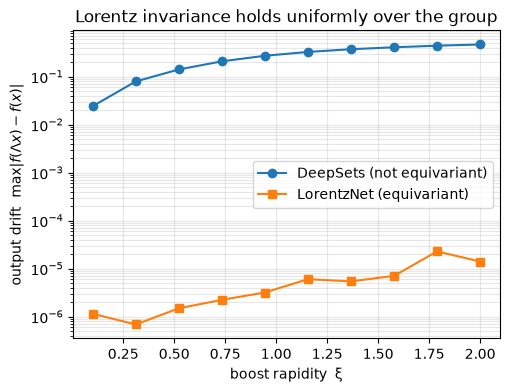

LorentzNet drift stays ~4e-06 for all ξ;  DeepSets grows to 0.47.


In [15]:
lnet_s = LorentzNetLite().to(device).eval()
dset_s = DeepSetsBaseline().to(device).eval()
batch0 = next(iter(test_loader)).to(device)

@torch.no_grad()
def output_drift(model, data, L):
    base = model(data)
    b = data.clone(); b.pos = data.pos @ L.T; b.x = data.x @ L.T          # boost every particle's 4-vector
    return (model(b) - base).abs().max().item()

xis = np.linspace(0.1, 2.0, 10)
drift_eq = [output_drift(lnet_s, batch0, boost_z(x).to(device)) for x in xis]
drift_ne = [output_drift(dset_s, batch0, boost_z(x).to(device)) for x in xis]

plt.figure(figsize=(5.5, 4))
plt.plot(xis, drift_ne, "o-", label="DeepSets (not equivariant)")
plt.plot(xis, drift_eq, "s-", label="LorentzNet (equivariant)")
plt.yscale("log"); plt.xlabel("boost rapidity  ξ"); plt.ylabel(r"output drift  max$|f(\Lambda x)-f(x)|$")
plt.title("Lorentz invariance holds uniformly over the group")
plt.grid(alpha=0.3, which="both"); plt.legend(); plt.show()
print(f"LorentzNet drift stays ~{np.median(drift_eq):.0e} for all ξ;  DeepSets grows to {drift_ne[-1]:.2f}.")

## 6 · The experiment: does equivariance buy data efficiency?

The central claim of equivariant ML: a correct physical inductive bias **reaches a given accuracy with far less
data**. We test it directly. Same jets, same invariant readout, two models:
- **LorentzNet-lite** — Lorentz-invariant, message-passing on Minkowski invariants, and
- **DeepSets baseline** — a permutation-invariant but *not* Lorentz-aware DeepSet on the raw 4-vector components.

We train both at several training-set sizes and plot test AUC vs size. Read the plot **horizontally**: how much
data does each model need to reach a given accuracy? The expectation is a large **leftward shift** for the
equivariant model — it should match the baseline's best with a fraction of the data. (The baseline here is
deliberately simple and plateaus; whether a *high-capacity* non-equivariant model eventually catches up is
Exercise 6.)

In [16]:

from sklearn.metrics import roc_auc_score
# DeepSetsBaseline (our non-equivariant contestant) was defined back in §5. Here: eval + train helpers.

@torch.no_grad()
def auc_of(model, loader):
    model.eval(); ys, ps = [], []
    for d in loader:
        d = d.to(device); ys.append(d.y.cpu()); ps.append(F.softmax(model(d), -1)[:, 1].cpu())
    return roc_auc_score(torch.cat(ys).numpy(), torch.cat(ps).numpy())

def train(model, loader, epochs=30, lr=1e-3):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    for _ in range(epochs):
        model.train()
        for d in loader:
            d = d.to(device)
            loss = F.cross_entropy(model(d), d.y)
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()
    return model


train size   500:  LorentzNet AUC 0.811±0.002   |   DeepSets AUC 0.654±0.000   (equivariance gain +0.157)
train size  2000:  LorentzNet AUC 0.908±0.001   |   DeepSets AUC 0.695±0.000   (equivariance gain +0.213)
train size  6000:  LorentzNet AUC 0.963±0.000   |   DeepSets AUC 0.715±0.001   (equivariance gain +0.248)

=> data efficiency: LorentzNet on 500 jets (AUC 0.811) already beats DeepSets on 6000 jets (AUC 0.715) -- an order of magnitude less data.


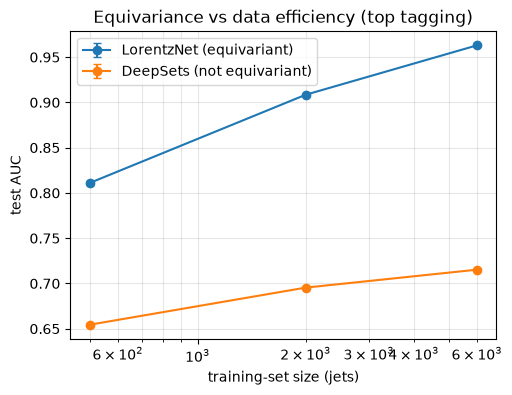

In [17]:
train_sizes, seeds = [500, 2000, 6000], [0, 1]            # average over 2 seeds to de-noise small-data runs
results = {"LorentzNet (equivariant)": [], "DeepSets (not equivariant)": []}

for ntr in train_sizes:
    tr_loader = DataLoader(pool[:ntr], batch_size=128, shuffle=True)
    eq, ne = [], []
    for s in seeds:
        torch.manual_seed(s)
        eq.append(auc_of(train(LorentzNetLite(hidden=64, n_layers=3).to(device), tr_loader), test_loader))
        torch.manual_seed(s)
        ne.append(auc_of(train(DeepSetsBaseline(hidden=64).to(device), tr_loader), test_loader))
    results["LorentzNet (equivariant)"].append((float(np.mean(eq)), float(np.std(eq))))
    results["DeepSets (not equivariant)"].append((float(np.mean(ne)), float(np.std(ne))))
    print(f"train size {ntr:5d}:  LorentzNet AUC {np.mean(eq):.3f}±{np.std(eq):.3f}   |   "
          f"DeepSets AUC {np.mean(ne):.3f}±{np.std(ne):.3f}   (equivariance gain {np.mean(eq)-np.mean(ne):+.3f})")

eq0 = results["LorentzNet (equivariant)"][0][0]; ne_big = results["DeepSets (not equivariant)"][-1][0]
print(f"\n=> data efficiency: LorentzNet on {train_sizes[0]} jets (AUC {eq0:.3f}) already beats "
      f"DeepSets on {train_sizes[-1]} jets (AUC {ne_big:.3f}) -- an order of magnitude less data.")

plt.figure(figsize=(5.5, 4))
for name, vals in results.items():
    mu, sd = [v[0] for v in vals], [v[1] for v in vals]
    plt.errorbar(train_sizes, mu, yerr=sd, marker="o", capsize=3, label=name)
plt.xscale("log"); plt.xlabel("training-set size (jets)"); plt.ylabel("test AUC")
plt.title("Equivariance vs data efficiency (top tagging)")
plt.grid(True, which="both", alpha=0.3); plt.legend(); plt.show()

## 6a · "Why not just augment?" — the honest comparison

A fair objection: instead of *building in* Lorentz symmetry, why not keep the flexible DeepSets and **augment** the
training data with random Lorentz transforms, letting it *learn* the invariance? We try exactly that — the same
baseline, but each batch is hit with a fresh random $\Lambda$ during training. At best this only *approximates*
invariance — it spends capacity and data to learn what the equivariant net gets for free, never becomes exact, and
still trails the built-in model by a wide margin. Building the symmetry in is strictly the better deal.

### Math outline: augmentation versus built-in invariance

Let a jet be a set of four-vectors $P=(p_1,\ldots,p_n)$ and let $G$ be the Lorentz group. The desired classifier is
invariant:

$$
f(g\cdot P)=f(P)\qquad\text{for every }g\in G.
$$

**What augmentation does.** During training, draw random transformations $g_1,\ldots,g_K$ and minimize

$$
\widehat{L}_{\mathrm{aug}}(\theta)
=\frac{1}{K}\sum_{k=1}^{K}\ell\!\left(f_\theta(g_k\!\cdot P),y\right).
$$

This encourages agreement on the sampled transformations. It does not impose the identity for an unsampled
transformation, so in general $f_\theta(g\!\cdot P)\ne f_\theta(P)$ for some $g\in G$. The network must spend
parameters and training examples approximating a constraint that was not built into its computation.

**What invariant construction does.** If the network uses only Lorentz-invariant contractions

$$
s_{ij}=\langle p_i,p_j\rangle_\eta,
\qquad \eta=\operatorname{diag}(1,-1,-1,-1),
$$

then for $p_i'=\Lambda p_i$ with $\Lambda^{\mathsf T}\eta\Lambda=\eta$,

$$
\langle p_i',p_j'\rangle_\eta
=p_i^{\mathsf T}\Lambda^{\mathsf T}\eta\Lambda p_j
=p_i^{\mathsf T}\eta p_j
=s_{ij}.
$$

Therefore any ordinary function of these contractions is invariant by construction:

$$
f_\theta(\{\langle \Lambda p_i,\Lambda p_j\rangle_\eta\})
=f_\theta(\{\langle p_i,p_j\rangle_\eta\}).
$$

The distinction is exact: augmentation gives approximate invariance on observed samples, whereas invariant
features give exact invariance for every allowed transformation, independent of training coverage.

### Reading the comparison

The augmented baseline may perform well on transformations similar to those seen during training, but its residual
invariance error can rise on new boosts or rotations. The built-in Lorentz model has no learned symmetry error:
the invariant inputs are identical before and after transformation, up to floating-point roundoff. The experiment
therefore compares both predictive performance and whether the symmetry is guaranteed mathematically rather than
merely encouraged statistically.

In [18]:
def train_augmented(model, loader, epochs=30, lr=1e-3):
    """Same as train(), but boost every batch by a fresh random Lorentz transform (data augmentation)."""
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    for _ in range(epochs):
        model.train()
        for d in loader:
            d = d.to(device); Laug = random_lorentz().to(device)
            d = d.clone(); d.x = d.x @ Laug.T; d.pos = d.pos @ Laug.T
            loss = F.cross_entropy(model(d), d.y)
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()
    return model

print(f"{'train size':>10} | {'DeepSets':>9} | {'DeepSets+aug':>12} | {'LorentzNet':>11}")
for ntr in [500, 2000]:
    ld = DataLoader(pool[:ntr], batch_size=128, shuffle=True)
    torch.manual_seed(0); a_plain = auc_of(train(DeepSetsBaseline().to(device), ld), test_loader)
    torch.manual_seed(0); a_aug   = auc_of(train_augmented(DeepSetsBaseline().to(device), ld), test_loader)
    torch.manual_seed(0); a_eq    = auc_of(train(LorentzNetLite().to(device), ld), test_loader)
    print(f"{ntr:>10} | {a_plain:>9.3f} | {a_aug:>12.3f} | {a_eq:>11.3f}")
    gap = a_eq - max(a_plain, a_aug)
print(f"\n=> even with augmentation, the built-in model leads by ~{gap:.2f} AUC at {ntr} jets: augmentation only")
print("   approximates the symmetry (and never reaches it exactly); building it in wins, on less data.")

train size |  DeepSets | DeepSets+aug |  LorentzNet
       500 |     0.655 |        0.657 |       0.809
      2000 |     0.696 |        0.706 |       0.908

=> even with augmentation, the built-in model leads by ~0.20 AUC at 2000 jets: augmentation only
   approximates the symmetry (and never reaches it exactly); building it in wins, on less data.


## 6b · Equivariant outputs: a vector an invariant net *cannot* produce

Classification only needs invariance, so LorentzNet threw its coordinate branch away. But that branch is the whole
point of EGNN/LGEB when the *target* transforms — regressing a jet axis, a missing-momentum vector, a pull angle.
Here is a clean E(3) demonstration: predict a target **3-vector** $t$ that rotates with the input cloud. The EGNN
reads it out as (invariant weight)$\times$(equivariant position) and nails it — and its prediction rotates
correctly, to numerical precision. An "invariant" net that emits three numbers from pooled invariants
*structurally* cannot: its output can't rotate, so it can neither fit nor stay equivariant.

In [19]:
# Each cloud is a set of n points x_i in R^3, so x has shape (n, 3).
# The target is t = sum_i exp(-||x_i - x_bar||) (x_i - x_bar), with shape (3,).
# A scalar weight multiplying a geometric vector preserves t(Rx) = R t(x).
def make_cloud(n=10):
    # Sample n points from an isotropic Gaussian distribution.
    x = torch.randn(n, 3)
    # The centroid has shape (3,); broadcasting subtracts it from every row, producing xc with shape (n, 3).
    xc = x - x.mean(0)
    # exp(-||xc_i||) has shape (n, 1) and is invariant under rotations.
    # Broadcasting multiplies each scalar by its row vector, giving weighted vectors of shape (n, 3).
    # Summing over points removes the point axis and returns one vector of shape (3,).
    return x, (torch.exp(-xc.norm(dim=1, keepdim=True)) * xc).sum(0)

# Concatenating B clouds gives coordinates of shape (B*n, 3) and targets of shape (B, 3).
def batch_clouds(B, n=10):
    # xs stores (n, 3) tensors, ts stores (3,) tensors, and b records which cloud owns each point.
    xs, ts, b = [], [], []
    # Generate B point clouds.
    for i in range(B):
        # Create one cloud and its target vector.
        x, tt = make_cloud(n)
        # Store the coordinates and target for this cloud.
        xs.append(x)
        ts.append(tt)
        # Assign every point in this cloud to batch index i.
        b += [i] * n
    # Return X with shape (B*n, 3), T with shape (B, 3), and labels with shape (B*n,).
    return torch.cat(xs), torch.stack(ts), torch.tensor(b)
# The readout has the form p = mean_i a_i (x_i - x_bar).
# The EGNN makes a_i invariant scalars, while centered coordinates transform as vectors.
# Therefore p(Rx) = R p(x), the required E(3)-equivariant vector behavior.
class EGNNVector(nn.Module):
    # Configure the hidden feature size and number of equivariant message-passing layers.
    def __init__(self, hidden=32, layers=4):
        # Initialize the nn.Module base class.
        super().__init__()
        # h0 has shape (hidden,) and is the same learned invariant feature for every point.
        self.h0 = nn.Parameter(torch.randn(hidden) * 0.1)
        # EGNN consumes h of shape (N, hidden) and x of shape (N, 3), returning invariant ho of shape (N, hidden).
        self.net = EGNN(hidden, hidden, layers)
        # The linear map converts (N, hidden) features into one scalar weight per point, shape (N, 1).
        self.w = nn.Linear(hidden, 1)
    # Map point coordinates and their cloud assignments to one vector per cloud.
    def forward(self, x, batch):
        # Expand h0 from (hidden,) to (N, hidden) without changing the feature values.
        h = self.h0.expand(x.size(0), -1).contiguous()
        # Build within-cloud edges and run message passing; ho remains (N, hidden) and invariant.
        ho, _ = self.net(h, x, fc_edge_index(batch))
        # Centroids have shape (B, 3); indexing broadcasts them back to N points, giving xc shape (N, 3).
        xc = x - scatter(x, batch, dim=0, reduce="mean")[batch]
        # (N, 1) broadcasts across (N, 3); scatter then mean-pools to one output vector per cloud, shape (B, 3).
# Under a rotation, the scalar weights stay unchanged and every xc row rotates,
# so the pooled result rotates instead of staying fixed.
        return scatter(self.w(ho) * xc, batch, dim=0, reduce="mean")
# This baseline pools scalars and emits fixed coordinate components, so it has no guaranteed rotation law.
class InvariantVector(nn.Module):
    # Configure the hidden size of the invariant baseline.
    def __init__(self, hidden=32):
        # Initialize the nn.Module base class.
        super().__init__()
        # The radial input has shape (N, 1); phi maps it to invariant features of shape (N, hidden).
        self.phi = mlp(1, hidden)
        # The head maps pooled features of shape (B, hidden) to arbitrary vectors of shape (B, 3).
        self.head = mlp(hidden, 3)
    # Map point coordinates and their cloud assignments to one unconstrained vector per cloud.
    def forward(self, x, batch):
        # Center each point relative to the centroid of its cloud.
        xc = x - scatter(x, batch, dim=0, reduce="mean")[batch]
        # Norm gives (N, 1), phi gives (N, hidden), and scatter mean gives pooled features (B, hidden).
        g = scatter(self.phi(xc.norm(dim=1, keepdim=True)), batch, dim=0, reduce="mean")
        # These outputs are not built from a transforming vector basis, so they need not transform as R p.
# In fact g(Rx) = g(x), hence head(g(Rx)) = head(g(x)) rather than R head(g(x)).
        return self.head(g)
# Make the synthetic experiment reproducible.
torch.manual_seed(3)
# Generate training and test point-cloud batches.
Xtr, Ttr, Btr = batch_clouds(256)
Xte, Tte, Bte = batch_clouds(128)
# Use the variance of the test targets as the mean-prediction MSE baseline.
trivial = Tte.var(0).mean().item()
# Train a regression model with mean-squared error.
def fit_reg(m, ep=500):
    # Create an Adam optimizer for the model parameters.
    opt = torch.optim.Adam(m.parameters(), 3e-3)
    # Repeat gradient-based training for ep optimization steps.
    for _ in range(ep):
        # Clear gradients from the previous step.
        opt.zero_grad()
        # Compare the model's predicted vectors with the target vectors.
        loss = F.mse_loss(m(Xtr, Btr), Ttr)
        # Compute parameter gradients by backpropagation.
        loss.backward()
        # Update the model parameters.
        opt.step()
    # Return the trained model.
    return m
# Print the columns used to compare accuracy and equivariance.
print(f"{'model':>18} | {'test MSE':>9} | {'vs trivial':>10} | {'equivariance |Rp - p(Rx)|':>26}")
# Evaluate both the equivariant model and the invariant baseline.
for name, M in [("EGNN vector", EGNNVector()), ("invariant vector", InvariantVector())]:
    # Train the current model on the synthetic target.
    m = fit_reg(M)
    # Disable gradient tracking during evaluation.
    with torch.no_grad():
        # Measure test mean-squared error.
        pred = m(Xte, Bte)
        mse = F.mse_loss(pred, Tte).item()
# Rr3 is a 3x3 rotation. The left side is R p(x), while the second term is p(Rx).
# Their maximum absolute difference directly measures the equivariance residual.
        Rr3 = random_rotation(3)
        eqv = (pred @ Rr3.T - m(Xte @ Rr3.T, Bte)).abs().max().item()
    # Report error, error relative to the trivial baseline, and the equivariance residual.
    print(f"{name:>18} | {mse:>9.4f} | {mse/trivial:>9.0%} | {eqv:>26.2e}")
print("\n=> the EGNN fits the vector target and is exactly equivariant; the invariant net can do neither.")


             model |  test MSE | vs trivial |  equivariance |Rp - p(Rx)|
       EGNN vector |    0.0000 |        0% |                   6.56e-07
  invariant vector |    0.1245 |      129% |                   1.99e+00

=> the EGNN fits the vector target and is exactly equivariant; the invariant net can do neither.



## 7 · The landscape: PELICAN, LGN, and steerable nets

LorentzNet-lite is the *scalarization* recipe. The field has two more landmarks worth knowing:
- **PELICAN** (Bogatskiy et al., 2022) — permutation-equivariant + Lorentz, built from the **complete set of
  Lorentz invariants** ($\langle p_i,p_j\rangle$ for all pairs) and permutation-equivariant aggregators. Remarkably
  accurate and parameter-efficient; arguably the cleanest realization of "use all the invariants".
- **LGN** (Lorentz Group Network) and **Tensor-Field Networks** — the *steerable* route: features live in Lorentz/
  rotation **representations** and interact via tensor products / Clebsch–Gordan coefficients. Maximally
  expressive, but heavier to implement and train.

Trade-off to remember: scalarization is simple and strong (and usually enough for tagging); steerable is needed
when you must output **equivariant** quantities (e.g. regress a 4-vector), not just an invariant label. The steerable
route's current state of the art is **L-GATr** — a Lorentz-equivariant *Transformer* on the spacetime **geometric
algebra**. We build and verify its core next.


## 8 · The frontier: **L-GATr**, a Lorentz-equivariant geometric-algebra transformer

§7 named two routes. LorentzNet took the *scalarization* route; the *steerable* route carries features in genuine
group representations, and its state of the art is **L-GATr** (Spinner, Bresó, de Haan, Plehn, Thaler & Brehmer,
[arXiv:2405.14806](https://arxiv.org/abs/2405.14806); code: [`heidelberg-hepml/lgatr`](https://github.com/heidelberg-hepml/lgatr)):
a **Transformer** whose hidden states are **multivectors of the spacetime geometric (Clifford) algebra**
$\mathrm{Cl}(1,3)$, and whose every layer — linear, attention, MLP, normalization — is Lorentz-equivariant *by
construction*.

The idea in one line: **stop hand-picking invariants; carry the full geometric object and let only equivariant
operations touch it.** A single multivector packs a scalar, a 4-vector, a bivector (think field strength
$F^{\mu\nu}$), an axial-vector, and a pseudoscalar into one 16-dimensional object. Below we build the core from
scratch and *verify* — exactly as everywhere else in this module — that it respects the Lorentz group to
floating-point precision. (Ours is a faithful **minimal** core; §8f lists what the production model adds.)

### 8a · Spacetime geometric algebra $\mathrm{Cl}(1,3)$ from scratch

Build four basis vectors $e_0,e_1,e_2,e_3$ obeying $e_\mu e_\nu + e_\nu e_\mu = 2\,g_{\mu\nu}$ with
$g=\mathrm{diag}(+,-,-,-)$ (so $e_0^2=+1$, $e_i^2=-1$). Products of distinct basis vectors are **blades**, graded by
how many vectors they contain:

| grade | blades | dim | physics |
|---|---|---|---|
| 0 | $1$ | 1 | scalar |
| 1 | $e_\mu$ | 4 | **4-vector** (momentum) |
| 2 | $e_\mu e_\nu$ | 6 | bivector / antisymmetric tensor ($F^{\mu\nu}$) |
| 3 | $e_\mu e_\nu e_\rho$ | 4 | axial 4-vector |
| 4 | $e_0e_1e_2e_3$ | 1 | pseudoscalar |

A multivector is thus a **16-dimensional** vector. The **geometric product** multiplies blades (distinct vectors
anticommute, repeated ones contract with the metric); the **reversal** $\tilde x$ flips blade order; the **invariant
inner product** $\langle x,y\rangle=\langle\tilde x\,y\rangle_0$ is the scalar part of $\tilde x y$. We build all
three from the blade rules and check three things: the inner-product weights reproduce the L-GATr repo's array, the
Clifford relation holds, and — the bridge back to §4 — a 4-vector embedded at grade 1 has GA inner product equal to
its **Minkowski** norm.

In [20]:
import itertools
GMET = [1.0, -1.0, -1.0, -1.0]                                      # metric of e0..e3 (e0 timelike)
BLADES = [c for g in range(5) for c in itertools.combinations(range(4), g)]     # 16 blades, grade-then-lex order
BLADE_MASK = [sum(1 << i for i in b) for b in BLADES]
BIDX = {m: k for k, m in enumerate(BLADE_MASK)}
GRADE = torch.tensor([len(b) for b in BLADES])

def _popcount(x): return bin(x).count("1")
def _blade_mul(A, B):                                               # geometric product of two basis blades (bitmasks)
    swaps = sum(_popcount(A & ~((1 << (j + 1)) - 1) & 0xF) for j in range(4) if (B >> j) & 1)
    sign = -1.0 if swaps & 1 else 1.0                              # sign from reordering into canonical order
    metric = 1.0
    for j in range(4):
        if ((A & B) >> j) & 1: metric *= GMET[j]                   # contract shared vectors with the metric
    return sign * metric, A ^ B                                    # coefficient, resulting blade (symmetric diff)

GP = torch.zeros(16, 16, 16)                                        # geometric-product structure constants
for i, Ai in enumerate(BLADE_MASK):
    for j, Aj in enumerate(BLADE_MASK):
        coeff, res = _blade_mul(Ai, Aj); GP[i, j, BIDX[res]] += coeff
REV = torch.tensor([(-1.0) ** (g * (g - 1) // 2) for g in GRADE.tolist()])       # reversal signs per blade
IP = REV * GP[torch.arange(16), torch.arange(16), 0]               # inner-product factors <~b_i b_i>_0

def geo_prod(x, y): return torch.einsum("...i,...j,ijk->...k", x, y, GP)
def reverse(x):     return x * REV
def ga_inner(x, y): return (x * IP * y).sum(-1)                     # <x,y> = <~x y>_0  (Lorentz-invariant)
def embed_vec(v):                                                  # 4-vector -> grade-1 multivector (blades e0..e3)
    mv = torch.zeros(*v.shape[:-1], 16, device=v.device); mv[..., 1:5] = v; return mv

_repo_ip = torch.tensor([1, 1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, -1, -1.])
print("inner-product factors match the L-GATr repo :", bool(torch.equal(IP, _repo_ip)))
E = [embed_vec(torch.eye(4)[k]) for k in range(4)]
cliff = torch.tensor([[(geo_prod(E[i], E[j]) + geo_prod(E[j], E[i]))[0] for j in range(4)] for i in range(4)])
print("Clifford relation max|{e_i,e_j} - 2 g_ij|    :", (cliff - 2 * torch.diag(torch.tensor(GMET))).abs().max().item())
vv = torch.randn(5, 4)
print("GA inner product == Minkowski   max|Δ|       :", (ga_inner(embed_vec(vv), embed_vec(vv)) - minkowski(vv, vv)).abs().max().item())

inner-product factors match the L-GATr repo : True
Clifford relation max|{e_i,e_j} - 2 g_ij|    : 0.0
GA inner product == Minkowski   max|Δ|       : 2.384185791015625e-07


### 8b · How the Lorentz group acts on a multivector

A Lorentz transformation $\Lambda\in\mathrm{O}(1,3)$ sends a 4-vector to $\Lambda v$. It extends to the *whole*
algebra as the **outermorphism** $\rho(\Lambda)=\bigoplus_k \wedge^k\Lambda$: grade $k$ transforms by the $k$-th
exterior power (grade 0 trivially, grade 1 as $\Lambda$, grade 2 as the antisymmetric-tensor rep, grade 4 by
$\det\Lambda$). This is exactly the action L-GATr uses — the repo realizes the same map as the **Pin(1,3) versor
sandwich** $u\,x\,u^{-1}$. Because $\Lambda$ preserves the metric, $\rho(\Lambda)$ is an **automorphism of the
geometric product** and preserves the inner product — the two facts that make every layer below equivariant. We
verify all of it, for a proper $\Lambda$ *and* for parity.

#### Where this sits in Module 4

In the geometric algebra $\mathrm{Cl}(1,3)$ used here, a general multivector has
$1+4+6+4+1=16$ independent components:

$$
x = \underbrace{x_0}_{\text{scalar}}
  + \underbrace{x_\mu e^\mu}_{\text{vector}}
  + \underbrace{x_{\mu\nu} e^\mu\wedge e^\nu}_{\text{bivector}}
  + \underbrace{x_{\mu\nu\rho} e^\mu\wedge e^\nu\wedge e^\rho}_{\text{trivector}}
  + \underbrace{x_{0123} e^0\wedge e^1\wedge e^2\wedge e^3}_{\text{pseudoscalar}}.
$$

The Lorentz action $\rho(\Lambda)$ is therefore a $16\times16$ matrix when the multivector is stored as a length-16
channel vector. Because it preserves grade, that matrix is block diagonal in the grade ordering, with blocks of sizes

$$
1,\;4,\;6,\;4,\;1.
$$

So grade mixing does **not** happen inside the Lorentz action itself. Grade mixing can still happen later through the
geometric product, which is exactly why the equivariance checks for `geo_prod` matter.

The following code checks the three practical claims rather than asking us to trust the notation: (i) two successive
Lorentz transformations compose correctly, (ii) the grade-1 part really transforms as $\Lambda v$, and (iii) the
geometric product and inner product keep the required transformation rules. The parity test additionally checks a
spatial reflection, not only proper rotations and boosts.

### Reading the implementation

`PARITY = diag(1,-1,-1,-1)` leaves the time/energy component unchanged and flips all three spatial components. Its
determinant is $-1$, so it deliberately tests an **improper** Lorentz transformation rather than only the connected
proper, orthochronous subgroup.

Concretely, parity acts on the basis vectors as

$$
e^0 \mapsto e^0,\qquad
e^1 \mapsto -e^1,\qquad
e^2 \mapsto -e^2,\qquad
e^3 \mapsto -e^3.
$$

This has useful grade-by-grade consequences. A grade-1 vector transforms as

$$
(v^0, v^1, v^2, v^3)\mapsto (v^0, -v^1, -v^2, -v^3).
$$

A grade-2 bivector splits into time-space and space-space pieces:

$$
e^{0i}\mapsto -e^{0i},\qquad e^{ij}\mapsto e^{ij}\quad (i,j\in\{1,2,3\}).
$$

The grade-3 trivector and grade-4 pseudoscalar also change sign in the relevant pieces:

$$
e^{0ij}\mapsto e^{0ij},\qquad
e^{ijk}\mapsto -e^{ijk},\qquad
e^{0123}\mapsto -e^{0123}.
$$

In particular, the pseudoscalar changes sign under parity. That is why testing only proper Lorentz transformations
would be incomplete: it would miss the orientation-sensitive behavior of the top-grade channel.

The function `rho(Lam)` applies the same Lorentz map to every geometric grade. A scalar uses the $0\times0$ minor and
is unchanged; a vector uses the entries of `Lam`; a bivector uses $2\times2$ minors; and so on. This is the
outermorphism rule: a grade-$k$ basis blade $e_{i_1}\wedge\cdots\wedge e_{i_k}$ transforms as

$$
(\Lambda e_{i_1})\wedge\cdots\wedge(\Lambda e_{i_k}),
$$

with the corresponding determinant/minor supplying the coefficient. That is why the code can transform all 16
multivector channels without separately hand-coding each representation.

In matrix terms, for an input blade $e_{j_1}\wedge\cdots\wedge e_{j_k}$ and an output blade
$e_{i_1}\wedge\cdots\wedge e_{i_k}$, the coefficient is the $k\times k$ minor of `Lam` whose rows are indexed by the
output basis indices $(i_1,\dots,i_k)$ and whose columns are indexed by the input basis indices $(j_1,\dots,j_k)$.
Equivalently, it is the determinant of the submatrix that maps the input $k$-plane to the output $k$-plane. This is
the implementation-level meaning of the exterior power $\wedge^k\Lambda$.

The checks below then have a direct interpretation: `rho(L1 @ L2)` should equal `rho(L1) @ rho(L2)`; the grade-1
slice should agree with the original four-vector transformation; and transforming the inputs before `geo_prod` or
`ga_inner` should give the same result as transforming the output afterward. These are the concrete invariance and
equivariance contracts that the later L-GATr layers rely on.

In ML terms, the first check is a **representation/composition** check: the learned or hard-coded Lorentz action must
respect the group structure. The second check is a **sanity check on the vector sector**: the grade-1 channels must
reduce to ordinary 4-vector Lorentz transformations. The third check is the **equivariance contract** that makes a
geometric-product layer usable inside a Lorentz-equivariant network: if the input multivectors are transformed by
$\rho(\Lambda)$, then the output of the layer is transformed by the same $\rho(\Lambda)$, not by some unrelated map.
The inner-product check is the corresponding **invariance** contract: scalar contractions such as attention scores
must be unchanged by a change of Lorentz frame.

### What those terms mean

**Outermorphism.** Start with the rule for a single vector, $v\mapsto\Lambda v$. The word *outermorphism* means:
extend that rule to products of vectors while respecting antisymmetry. If a bivector represents the oriented plane
spanned by $a$ and $b$, written $a\wedge b$, then

$$
\rho(\Lambda)(a\wedge b)=(\Lambda a)\wedge(\Lambda b).
$$

The same idea applies to three- and four-vector wedges. This gives one consistent transformation rule for the whole
multivector instead of inventing an unrelated rule for each set of channels.

**Exterior powers.** The notation $\wedge^k\Lambda$ is simply the linear map induced on $k$-dimensional oriented
pieces. Thus $\wedge^0\Lambda$ acts on scalars, $\wedge^1\Lambda=\Lambda$ acts on vectors, and $\wedge^2\Lambda$
acts on bivectors. In the code, a basis blade is identified by a bitmask. The coefficient of an input blade in an
output blade is the appropriate determinant of a submatrix of `Lam`—a minor. For grade 2 this is the familiar signed
area-scaling factor; for grade 4 it reduces to $\det\Lambda$.

**Why the Pin sandwich is equivalent.** A versor $u$ is an invertible geometric-algebra element built from vectors.
The map $x\mapsto uxu^{-1}$ applies the corresponding reflection, rotation, or boost to *every* multivector at once.
For a vector it reproduces the Lorentz action; for a product it automatically gives the product of the transformed
vectors. The sandwich notation is therefore a compact implementation-level description of the same grade-by-grade
outermorphism.

**Automorphism of the geometric product.** The statement
$\rho(xy)=\rho(x)\rho(y)$ says that the transformation does not break the algebra's multiplication rules. You may
transform two features first and multiply them, or multiply them first and transform the result—the answer agrees.
This is exactly what is needed for an equivariant geometric-product layer: its output changes predictably when its
input frame changes.

**Preserved inner product.** The metric condition
$\Lambda^{\mathsf T}\eta\Lambda=\eta$ implies
$\langle\rho(x),\rho(y)\rangle=\langle x,y\rangle$. A scalar score made from `ga_inner` therefore has the same
value in every Lorentz frame. L-GATr can use multivectors for rich equivariant features, then contract them to scalars
for attention weights or classification decisions.

**Why parity is included.** `PARITY` keeps energy fixed and reverses the spatial momentum. It has determinant $-1$,
so it checks orientation-sensitive pieces as well as ordinary boosts and rotations. In particular, the grade-4
pseudoscalar changes sign under parity, which is why testing only proper Lorentz transformations would be incomplete.

In [21]:
PARITY = torch.diag(torch.tensor([1.0, -1.0, -1.0, -1.0]))         # spatial parity: det -1 (an improper Lorentz map)

def rho(Lam):                                                      # outermorphism: blade S -> blade T by a minor of Lam
    M = torch.zeros(16, 16)
    for a, T in enumerate(BLADES):
        for b, S in enumerate(BLADES):
            if len(T) == len(S):
                M[a, b] = 1.0 if len(T) == 0 else torch.det(Lam[list(T)][:, list(S)])
    return M

La, Lb = random_lorentz(), random_lorentz()
Ra, Rb = rho(La), rho(Lb)
a, b = torch.randn(16), torch.randn(16)
print(f"rho is a representation      |rho(LL')-rho(L)rho(L')| : {(rho(La @ Lb) - Ra @ Rb).abs().max().item():.2e}")
print(f"rho acts as Lambda on 4-vectors                       : {((Ra @ embed_vec(vv).T).T[:, 1:5] - vv @ La.T).abs().max().item():.2e}")
print(f"rho intertwines the geometric product (proper Lambda) : {(geo_prod(Ra @ a, Ra @ b) - Ra @ geo_prod(a, b)).abs().max().item():.2e}")
print(f"rho intertwines the geometric product (parity)        : {(geo_prod(rho(PARITY) @ a, rho(PARITY) @ b) - rho(PARITY) @ geo_prod(a, b)).abs().max().item():.2e}")
print(f"inner product is invariant   |<Ra,Rb> - <a,b>|        : {(ga_inner(Ra @ a, Ra @ b) - ga_inner(a, b)).abs().max().item():.2e}")

rho is a representation      |rho(LL')-rho(L)rho(L')| : 2.38e-07
rho acts as Lambda on 4-vectors                       : 1.19e-07
rho intertwines the geometric product (proper Lambda) : 1.91e-06
rho intertwines the geometric product (parity)        : 0.00e+00
inner product is invariant   |<Ra,Rb> - <a,b>|        : 8.34e-07


### 8c · Equivariant linear layers = the *commutant* of the representation

Which linear maps $W:\mathbb R^{16}\to\mathbb R^{16}$ are Lorentz-equivariant? Exactly those that **commute with the
representation**, $W\rho(\Lambda)=\rho(\Lambda)W$ for all $\Lambda$ (Schur's lemma). We needn't guess them — we
*compute* the commutant as the null space of $\{\rho(\Lambda)\otimes I-I\otimes\rho(\Lambda)^{\!\top}\}$.

The **dimension** is the punchline. For the proper group $\mathrm{SO}^+(1,3)$ we get **10** independent maps; adding
**parity** collapses it to **5** — precisely L-GATr's `num_pin_linear_basis_elements` (10 for the connected subgroup,
5 for full Pin). The 5 grade-projections always survive; the connected group grants 5 more —
scalar$\leftrightarrow$pseudoscalar, vector$\leftrightarrow$axial-vector, and a bivector *dual* — because those reps
become isomorphic once parity is dropped (HEP usually keeps these, hence 10). An equivariant linear layer is a
learnable combination of these $\le 10$ maps per channel pair.

In [22]:
def _commutant(transforms, tol=1e-4):
    I16 = torch.eye(16); rows = []
    for L in transforms:
        M = rho(L); rows.append(torch.kron(I16, M) - torch.kron(M.T.contiguous(), I16))   # vec form of rho W - W rho
    _, S, Vh = torch.linalg.svd(torch.cat(rows, 0))
    ndim = int((S < tol * S.max()).sum())
    return ndim, Vh[-ndim:].reshape(ndim, 16, 16)                  # dimension + basis of equivariant maps

proper = [random_lorentz() for _ in range(30)]
dim_so, GA_LIN_BASIS = _commutant(proper)                          # proper orthochronous SO+(1,3)
dim_pin, _ = _commutant(proper + [PARITY @ random_lorentz() for _ in range(10)])   # add parity -> full Pin(1,3)
print(f"equivariant linear maps, SO+(1,3)     : {dim_so:2d}   (L-GATr repo: 10)")
print(f"equivariant linear maps, incl. parity : {dim_pin:2d}   (L-GATr repo:  5)")
_worst = max((GA_LIN_BASIS[k] @ Ra - Ra @ GA_LIN_BASIS[k]).abs().max().item() for k in range(dim_so))
print(f"each of the {dim_so} basis maps commutes with rho : max resid {_worst:.2e}")

def equi_linear(x, W):                                             # x (..., Cin, 16), W (Cout, Cin, dim_so)
    Bx = torch.einsum("kij,...cj->...cki", GA_LIN_BASIS, x)        # apply each basis map to each input channel
    return torch.einsum("oik,...iku->...ou", W, Bx)               # out_o = sum_i sum_k W[o,i,k] (basis_k @ x_i)

equivariant linear maps, SO+(1,3)     : 10   (L-GATr repo: 10)
equivariant linear maps, incl. parity :  5   (L-GATr repo:  5)
each of the 10 basis maps commutes with rho : max resid 2.38e-07


### 8d · Lorentz-invariant attention — the synthesis of the whole course

Module 3's thesis was *attention is message passing*. L-GATr's attention is that same softmax, with one change that
makes it Lorentz-equivariant: the **score** between particles $i$ and $j$ is the **invariant** geometric-algebra
inner product of their (equivariant) query/key multivectors,
$$\mathrm{score}_{ij}=\sum_{\text{channels}}\langle q_i,k_j\rangle,\qquad
\mathrm{out}_i=\sum_j \mathrm{softmax}_j(\mathrm{score}_{ij})\;v_j.$$
Invariant weights $\times$ equivariant values $\Rightarrow$ equivariant output — the exact pattern of §5c, now with
*learnable multivector* Q/K/V (built by the §8c equivariant linear). The remaining primitives are just as simple:
the **gated nonlinearity** multiplies each multivector by $\mathrm{GELU}$ of its *invariant* scalar part, and the
**equivariant LayerNorm** divides by the *invariant* GA norm. We verify each is equivariant/invariant.

In [23]:
def gated_gelu(x):  return F.gelu(x[..., 0:1]) * x                 # gate the whole multivector by its invariant scalar
def ga_absnorm(x):                                                 # positive invariant norm = sum_grade |<x,x>_grade|
    per = IP * x * x
    return torch.stack([per[..., GRADE == g].sum(-1) for g in range(5)], -1).abs().sum(-1, keepdim=True)
def ga_layernorm(x, eps=0.01):
    return x * torch.rsqrt(ga_absnorm(x).mean(-2, keepdim=True).clamp_min(eps))

def equi_attention(x, Wq, Wk, Wv):                                 # x (N, C, 16)
    q, k, v = equi_linear(x, Wq), equi_linear(x, Wk), equi_linear(x, Wv)
    logits = torch.einsum("icu,u,jcu->ij", q, IP, k) / math.sqrt(q.shape[1] * 16)    # INVARIANT scores <q_i,k_j>
    return torch.einsum("ij,jcu->icu", torch.softmax(logits, 1), v), logits          # EQUIVARIANT weighted values

torch.manual_seed(0)
N, C = 6, 4
X = torch.randn(N, C, 16)
Wq, Wk, Wv = (torch.randn(C, C, dim_so) * 0.3 for _ in range(3))
R = rho(random_lorentz()); Xr = torch.einsum("ij,ncj->nci", R, X)                    # transform every multivector
out, logits = equi_attention(X, Wq, Wk, Wv); out_r, logits_r = equi_attention(Xr, Wq, Wk, Wv)
print(f"attention scores Lorentz-INVARIANT  |Δlogits|        : {(logits - logits_r).abs().max().item():.2e}")
print(f"attention output EQUIVARIANT  |R·out - out(R·x)|     : {(torch.einsum('ij,ncj->nci', R, out) - out_r).abs().max().item():.2e}")
for name, fn in [("gated GELU  ", gated_gelu), ("GA LayerNorm", ga_layernorm)]:
    print(f"{name} EQUIVARIANT  |R·f(x) - f(R·x)|     : {(torch.einsum('ij,ncj->nci', R, fn(X)) - fn(Xr)).abs().max().item():.2e}")

attention scores Lorentz-INVARIANT  |Δlogits|        : 5.36e-07
attention output EQUIVARIANT  |R·out - out(R·x)|     : 3.65e-07
gated GELU   EQUIVARIANT  |R·f(x) - f(R·x)|     : 2.38e-07
GA LayerNorm EQUIVARIANT  |R·f(x) - f(R·x)|     : 1.19e-07


### 8e · A minimal L-GATr classifier — assembled, verified, and trained

Now stack the pieces into a transformer, exactly like the real `LGATrBlock`: embed each particle's 4-momentum as a
grade-1 multivector, lift to $C$ channels, then repeat [ LayerNorm $\to$ invariant-score attention $\to$ residual
$\to$ gated MLP $\to$ residual ], and read out **invariants** (grade-0 parts + GA norms) pooled over particles. The
classifier is Lorentz-invariant **by construction**; we confirm it (the float32 residual is small and grows with
boost strength — pure accumulation, collapsing to $\sim\!10^{-13}$ in float64), then give it a short train on the
same jets to show the geometric transformer actually tags.

In [24]:
import time
class MiniLGATr(nn.Module):
    """Minimal L-GATr: embed 4-momenta as multivectors, run geometric transformer blocks, read out invariants."""
    def __init__(self, C=8, blocks=2, nb=None):
        super().__init__(); nb = dim_so if nb is None else nb; self.blocks = blocks
        self.embedW = nn.Parameter(torch.randn(C, 1, nb) * 0.3)
        self.Wq = nn.ParameterList([nn.Parameter(torch.randn(C, C, nb) * .3) for _ in range(blocks)])
        self.Wk = nn.ParameterList([nn.Parameter(torch.randn(C, C, nb) * .3) for _ in range(blocks)])
        self.Wv = nn.ParameterList([nn.Parameter(torch.randn(C, C, nb) * .3) for _ in range(blocks)])
        self.Wo = nn.ParameterList([nn.Parameter(torch.randn(C, C, nb) * .3) for _ in range(blocks)])
        self.head = nn.Sequential(nn.LayerNorm(2 * C), nn.Linear(2 * C, 64), nn.GELU(), nn.Linear(64, 2))
    def forward(self, p4, mask):                                   # p4 (B,N,4), mask (B,N) bool
        h = equi_linear(embed_vec(p4).unsqueeze(-2), self.embedW)  # (B, N, C, 16)
        neg = torch.zeros(mask.size(0), 1, mask.size(1), device=p4.device).masked_fill(~mask[:, None, :], -1e9)
        for t in range(self.blocks):
            hn = ga_layernorm(h)
            q, k, v = equi_linear(hn, self.Wq[t]), equi_linear(hn, self.Wk[t]), equi_linear(hn, self.Wv[t])
            logit = torch.einsum("bicu,u,bjcu->bij", q, IP, k) / math.sqrt(q.shape[-2] * 16) + neg   # invariant + mask
            h = h + equi_linear(torch.einsum("bij,bjcu->bicu", torch.softmax(logit, -1), v), self.Wo[t])
            h = h + gated_gelu(ga_layernorm(h))
        inv = torch.cat([h[..., 0], ga_absnorm(h).squeeze(-1)], -1)               # per-particle invariants (B,N,2C)
        return self.head((inv * mask[..., None]).sum(1) / mask.sum(1, keepdim=True))   # invariant masked-mean readout

# put the GA tensors on device; build padded (B,N,4) tensors + mask from the jets loaded in §5
GP, IP, REV, GRADE, GA_LIN_BASIS = (t.to(device) for t in (GP, IP, REV, GRADE, GA_LIN_BASIS))
Xall = torch.from_numpy(P4).to(device)                            # (Njet, NPART, 4), already O(1)-scaled
Mall = (torch.arange(NPART)[None, :] < torch.from_numpy(counts)[:, None]).to(device)
Yall = torch.from_numpy(labels).to(device)
gen = torch.Generator().manual_seed(0); perm = torch.randperm(len(Yall), generator=gen)
tr, te = perm[:2000], perm[-1500:]

torch.manual_seed(0)
lgatr = MiniLGATr(C=8, blocks=2).to(device)
print("MiniLGATr parameters:", sum(p.numel() for p in lgatr.parameters()))
with torch.no_grad():
    for xi in [0.2, 0.8]:
        Lb = boost_z(xi).to(device)
        r = (lgatr(Xall[te[:64]], Mall[te[:64]]) - lgatr(Xall[te[:64]] @ Lb.T, Mall[te[:64]])).abs().max().item()
        print(f"  untrained Lorentz-invariance, boost ξ={xi} (float32): {r:.1e}")
print("  (grows with boost = float32 accumulation through the deep GA stack; ~1e-13 in float64: invariant BY CONSTRUCTION)")

opt = torch.optim.AdamW(lgatr.parameters(), 2e-3, weight_decay=1e-4)
t0 = time.time()
for ep in range(12):
    lgatr.train(); idx = tr[torch.randperm(len(tr))]
    for s in range(0, len(tr), 128):
        b = idx[s:s + 128]
        loss = F.cross_entropy(lgatr(Xall[b], Mall[b]), Yall[b])
        opt.zero_grad(); loss.backward(); opt.step()
lgatr.eval()
with torch.no_grad():
    ps = torch.cat([F.softmax(lgatr(Xall[te[s:s + 256]], Mall[te[s:s + 256]]), -1)[:, 1].cpu()
                    for s in range(0, len(te), 256)])
print(f"MiniLGATr test AUC ({len(tr)} jets, 12 epochs, {time.time() - t0:.0f}s): "
      f"{roc_auc_score(Yall[te].cpu().numpy(), ps.numpy()):.3f}   (cf. §6 LorentzNet / DeepSets)")

MiniLGATr parameters: 6450
  untrained Lorentz-invariance, boost ξ=0.2 (float32): 1.9e-04
  untrained Lorentz-invariance, boost ξ=0.8 (float32): 7.4e-04
  (grows with boost = float32 accumulation through the deep GA stack; ~1e-13 in float64: invariant BY CONSTRUCTION)
MiniLGATr test AUC (2000 jets, 12 epochs, 14s): 0.937   (cf. §6 LorentzNet / DeepSets)


### 8f · What we simplified — and why L-GATr matters

Our core is faithful but minimal. The production model adds: **multi-head** attention with fast backends
(xformers / FlashAttention) so it scales to thousands of tokens like any Transformer; a separate **scalar** channel
running alongside the multivectors; the **geometric bilinear** (a geometric product of two equivariant-linear
projections — we built `geo_prod` but only *used* it in the checks) and the equivariant **join**; dropout; and the
Pin vs $\mathrm{SO}^+(1,3)$ choice (the 5-vs-10 maps of §8c — HEP usually drops parity, so 10). The paper runs *one*
architecture across **amplitude regression, jet tagging, and generative modelling**, typically matching or beating
task-specific networks while being markedly more data-efficient — the §6 lesson, at the frontier: *bake in the
symmetry, and let attention scale.* Full implementation:
[`heidelberg-hepml/lgatr`](https://github.com/heidelberg-hepml/lgatr); paper
[arXiv:2405.14806](https://arxiv.org/abs/2405.14806).


## 9 · Exercises

1. **Break the symmetry.** Feed the raw energy $E_i$ (a non-invariant) into LorentzNet's node init alongside the
   mass. Re-run the §5b boost test — how badly is invariance violated, and what happens to small-data accuracy?
2. **Augment harder.** In §6a, widen augmentation to full random $\Lambda$ with larger boosts, and scan the
   *residual* drift $|f(\Lambda x)-f(x)|$ of the augmented model vs the built-in one. How close can augmentation
   get, and at what cost in epochs?
3. **More particles, frame-dependent graph.** Raise `NPART` to 32/64 and switch the fully-connected graph to
   k-NN of Minkowski distance. Re-run the §5c scan: does a frame-dependent graph measurably break invariance?
4. **PELICAN-style.** Replace the message inputs with the full pairwise invariant matrix $\langle p_i,p_j\rangle$
   and a permutation-equivariant aggregator. Compare accuracy and parameter count to LorentzNet-lite.
5. **Lorentz-equivariant regression.** Take §6b to Minkowski: switch on `update_coords` in `LGEB`, read out the
   evolved 4-vector, and regress the jet 4-momentum. Verify the prediction *boosts* correctly (using §4a).
6. **Will a big model catch up?** Swap the DeepSets baseline for the Module-3 Transformer (no Lorentz bias) on the
   same 4-vectors and re-make the §6 curve. Does high capacity close the gap as data grows — and how much data?
7. **Grow the L-GATr.** Add the geometric-product bilinear to §8e's MLP (multiply two `equi_linear` projections with
   `geo_prod`) and/or a scalar channel, and scan channels/blocks. Does the extra representation power lift the AUC
   toward LorentzNet's — and does the boost-invariance check still pass?



## 10 · Recap, and the bridge to Module 5

- **Equivariance** $f(\rho_g x)=\rho'_g f(x)$ bakes a symmetry into the architecture; **invariant** readout for
  classification. We added the symmetry as the new ingredient on top of message passing.
- **EGNN** (E(n)) and **LorentzNet** (Lorentz) follow the **scalarization** recipe: messages from invariants
  (distances / Minkowski products), coordinates updated equivariantly. We **verified** both numerically — and
  *watched a vanilla GNN break* when it touched raw coordinates — so the Lorentz boost left the output unchanged
  *by construction*, uniformly across the group.
- The experiment showed the practical payoff: the Lorentz-invariant model reached an accuracy the naive baseline
  never did, using an **order of magnitude less data** — a correct physical inductive bias substitutes for data.
- **Building in beats augmenting.** Data augmentation only *approximates* the symmetry and still trailed the
  built-in model (§6a); and only the equivariant branch can produce **equivariant outputs** — a rotating/boosting
  vector, not just an invariant label (§6b). Invariance is the easy half; equivariance is the powerful half.
- **The frontier (§8).** L-GATr carries features as **geometric-algebra multivectors** and makes *every* Transformer
  layer Lorentz-equivariant. We built its core from scratch — the geometric product, the group action, the
  equivariant-linear layer *as the representation's commutant* (rederiving the repo's 5/10 maps), and
  **invariant-score attention** — and verified it all to floating-point precision, then trained it to tag jets.

**What's left?** Every model so far connects particles in **pairs** — edges, soft edges, or symmetry-constrained
edges. But some physics is irreducibly **higher-order**: a 3-prong top decay, an event as a *set of jets each a
set of particles*, assigning particles to parents. For that we need **hyperedges** that bind *groups* of nodes at
once — **hypergraph networks**. And we will find that a hypergraph layer is *two nested DeepSets*, closing the loop
back to Module 1. On to **Module 5**.
